# **第一次讀書會專案：對 PTT 房屋版「新青安」相關文章進行情緒分析**

**課程：** 社群媒體分析  
**教授：** 黃三益 老師  
**組別：** 第 12 組  
**組員：** 林永森 N124320002、盧鳳珠 N134320006、林㛄婷 N134020008、陳葳 N134320010、黃羽彤 N144020013、李玟娟 M145040001

---

## **專案背景與說明**

### **新青安政策簡介**
「新青年安心成家購屋優惠貸款」（簡稱新青安）由財政部於 2023 年 8 月正式推行，旨在減輕年輕首購族的購屋負擔。政策包含四大優惠：貸款額度上限提升至 1,000 萬元、貸款年限延長至 40 年、寬限期放寬至 5 年，並由政府加碼補貼利息至 1.775% 之地板利率。該政策雖顯著推升首購族進場意願，卻也因後續引發的房市過熱與人頭戶爭議，促使政府於 2024 年陸續增設「一生限貸一次」與「自住切結書」等管控措施。

### **專案動機**
自「新青安」貸款政策推行以來，房地產市場熱度與爭議並行。民眾對於該政策究竟是實現「購屋圓夢」的助力，還是「助漲房價」的推手存在嚴重分歧。隨後引發的「限貸令」與「銀行水位趨滿」等事件，更使社群輿論產生劇烈震盪，具備高度分析價值。本專案旨在透過數據分析，量化觀測社群對此政策的真實情感取向，探究民眾情緒如何受到關鍵議題的驅動與影響。

### **專案目的**
本專案量化觀測新青安在關鍵政策變動點後的情緒消長趨勢。透過「寬限期」、「銀行水位」、「排隊撥款」等核心關鍵字，分析影響民眾情緒的實質議題與社群痛點，並結合時間線觀測情緒波動，探討 PTT 社群討論作為政策反饋指標之可行性，以期為未來房市政策的制定與調整提供數據化參考。

---

## **報告大綱**

### **資料概況**
* **資料來源**：透過 TarFlow 蒐集 PTT 房屋版、政黑版、貸款版文章。
* **關鍵字**：新青安
* **時間範圍**：2023-08-01 ~ 2026-03-20
* **原始資料量**：共 4,646 篇文章
* **本次專案資料篩選**：僅採用「房屋版」文章。主因貸款版多為結構化表格且缺乏互動推文，難以媒合 LIWC 情緒字典；房政黑版則因政治極化與政黨攻防雜訊過多，易干擾政策情緒分析。房屋版為觀點產出中心，能精準反映受眾對新青安的真實焦慮與認同。


### **分析流程**

* **1. 前置作業與資料匯入**
    * 1.1 套件與參數
    * 1.2 資料匯入
    * 1.3 額外處理 (版別、主文/留言)  
* **2. 文本預處理**
    * 2.1 資料清洗
    * 2.2 自定義詞彙
    * 2.3 文本切分 (斷句、斷詞)
    * 2.4 停用字過濾
    * 2.5 同義詞處理
* **3. 情緒分析一 (Lexicon-based)**
    * 3.1 前置作業
    * 3.2 正負情緒詞彙分析
    * 3.3 正負文章趨勢分析
    * 3.4 正負情緒關鍵字
    * 3.5 重新計算情緒
    * 3.6 負面文章的文字雲      
* **4. 情緒分析二**
    * 4.1 套件安裝
    * 4.2 CKIP處理
    * 4.3 探索分析 - NER
    * 4.4 探索分析 - POS
    * 4.5 SnowNLP進行情緒分析
 * **5. 結論**   
---

# 1. 前置作業與資料匯入

## 1.1 套件與參數

In [2]:
isAnalysisComment = False # 是否為分析留言
artCatagory = ["home_sale", 'HatePolitics'] # 'home_sale', 'HatePolitics', 'Loan' ，留空為全抓


# colors = ["tab:green", "tab:orange"]
# colors = ["#00CEC9", "#FF7675"]
colors = ["#2980B9", "#C0392B"]
# colors = ["#6C5CE7", "#FAD390"]

In [3]:
# 用於資料處理與分析，像是把 Excel 或 CSV 檔案轉成表格（DataFrame）來操作
import pandas as pd

# 核心的中文斷詞工具，把長句子拆解成一個個有意義的詞彙
import jieba  

# 提取關鍵詞的工具（如 TF-IDF），幫妳從一大篇文字中直接抓出重點詞
import jieba.analyse

# 正規表示法（Regular Expression），用來清洗資料，例如過濾掉標點符號、網址或雜訊
import re

# 繪製文字雲的工具，會根據詞頻高低來調整圖片中字體的大小
from wordcloud import WordCloud

# 繪圖庫，負責把生成的文字雲圖片或是其他圖表顯示在螢幕上
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from datetime import datetime

c:\Users\p6267\AppData\Local\Programs\Python\Python312\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
# 設定圖的字體大小
plt.rcParams['font.size'] = 10

# 設定圖的中文字體 (無法顯示的話可以試試‘Microsoft JhengHei’字體)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS'] # Windows 中文字體

# 設定文字雲中文字體路徑
FontPath = 'raw_data/SourceHanSansTW-Regular.otf' # 設定字型

# plt.rcParams['font.sans-serif']=['SimHei'] #使 matplotilb 中文能正常顯示
fprop = fm.FontProperties(fname="./raw_data/SourceHanSansTW-Regular.otf")

# 設定整份 notebook 圖片的長寬與 dpi
plt.rcParams["figure.figsize"] = [6, 4]
plt.rcParams["figure.dpi"] = 150

## 1.2 資料匯入

In [5]:
orig_df = pd.read_csv('raw_data/Book_Club_Project_202308.csv')
orig_df.head(5) # SQL TOP(5) C# TAKE(5)

,system_id,artComment,artTitle,artDate,insertedDate,artContent,e_ip,artUrl,dataSource,artCatagory,artPoster
0,1,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""howardcd"", ""...",[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,2023-08-02 01:57:15,連結：\nhttps://money.udn.com/money/story/5621/73...,111.251.218.198,https://www.ptt.cc/bbs/home-sale/M.1690887173....,ptt,home_sale,humbler
1,2,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""hellogym"", ""...",[新聞]台中7月房市衰退4都之最這1區幾乎腰斬,2023-08-01 20:05:11,2023-08-02 01:57:17,https://udn.com/news/story/7325/7339682\n台中7月房...,180.217.66.179,https://www.ptt.cc/bbs/home-sale/M.1690891513....,ptt,home_sale,backpacker18
2,3,"[{""cmtStatus"": ""噓"", ""cmtPoster"": ""aq2272353712...",[新聞]房市低迷台南7月買賣移轉棟數五年來最冷,2023-08-01 23:38:55,2023-08-02 01:57:17,連結：\nhttps://house.udn.com/house/story/5889/73...,61.230.132.156,https://www.ptt.cc/bbs/home-sale/M.1690904337....,ptt,home_sale,hvariables
3,4,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""async"", ""cmt...",[新聞]減輕年輕人買房負擔！青安貸款升級版今上,2023-08-01 23:51:28,2023-08-02 01:57:17,減輕年輕人買房負擔！青安貸款升級版今上路 賴清德一張圖報你知\n\n連結：\nhttps:/...,77.111.245.10,https://www.ptt.cc/bbs/home-sale/M.1690905091....,ptt,home_sale,empliu
4,5,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""snow30288"", ...",Re:[閒聊]85年次以後的年輕工程師有多慘？,2023-08-02 01:28:01,2023-08-02 01:57:18,原文恕刪\n背景交代一下\n小弟正好85年次\n前年台大非電資科系碩班畢業\n上山非產線常日...,114.137.85.17,https://www.ptt.cc/bbs/home-sale/M.1690910883....,ptt,home_sale,kevinwu0116


## 1.3 額外處理 (版別、主文/留言)

In [6]:
# artCatagory 若有值(長度不為0)，則過濾出 artCatagory 列中包含指定類別的行
if len(artCatagory) > 0:
    orig_df = orig_df[orig_df['artCatagory'].isin(artCatagory)]

In [7]:
import ast

if(isAnalysisComment):
    # 將字串轉為 List
    df['cmtList'] = df['artComment'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])

    df_exploded = df.explode('cmtList').reset_index(drop=True)

    # 字典扁平化
    comments_flat = pd.json_normalize(df_exploded['cmtList'])

    cols_to_keep = [c for c in df_exploded.columns if c not in ['cmtList', 'cmtStatus']]
    df_final = pd.concat([df_exploded[cols_to_keep], comments_flat], axis=1)

    df_final['cmtContent'] = df_final['cmtContent'].str.replace('^:', '', regex=True)

    df_final = df_final.drop(columns=['artContent', 'artPoster', 'artDate'])
    df_final = df_final.rename(columns={'cmtDate': 'artDate'})
    df_final = df_final.rename(columns={'cmtContent': 'artContent'})
    df_final = df_final.rename(columns={'cmtPoster': 'artPoster'})

    df = df_final

    print(f"後續為進行推文分析，處理後的總筆數：{len(df_final)}")
    display(df_final.head(30))
else:
    print('後續為進行主文分析')

後續為進行主文分析


# 其他

In [8]:
# 建立一個計算詞頻的funciton，傳入參數為df的欄位
def show_word_freq(df_col):
    freq_df = pd.DataFrame(df_col.value_counts()).sort_values(by = ['count'], ascending = False).reset_index()
    # print(freq_df.head(10))
    return freq_df

In [9]:
# 建立一個繪製正負情緒趨勢圖的 function，傳入參數為正面和負面情緒的 y 軸數據，以及圖表標題
def plot_sentiment_trend(pos, neg , title_name, meanDay = 0):
    """
    function : 繪製正負情緒趨勢圖
    pos: 正面情緒的數據 (可以是原始 size 或 rolling 後的結果)
    neg: 負面情緒的數據
    meanDay: 滾動平均的天數(預設0表示不使用滾動平均)
    title_name: 圖表標題
    """
    # 1. 建立畫布
    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

    # 2. 畫線 (x 軸固定用 pos["artDate"], neg["artDate"])
    if meanDay > 0:
        pos_y = pos['size'].rolling(meanDay).mean()
        neg_y = neg['size'].rolling(meanDay).mean()
    else:
        pos_y = pos['size']
        neg_y = neg['size']

    ax.plot(pos["artDate"], pos_y, color=colors[0], label="positive", linewidth=2)
    ax.plot(neg["artDate"], neg_y, color=colors[1], label="negative", linewidth=2)

    # 3. 區域填充 (如果想開啟可以取消註解)
    # ax.fill_between(pos["artDate"], pos_y, color=colors[0], alpha=0.15)
    # ax.fill_between(neg["artDate"], neg_y, color=colors[1], alpha=0.15)

    # 4. 重複的裝飾設定通通放在這
    plt.xlabel("artDate", fontproperties=fprop)
    plt.ylabel('size', fontproperties=fprop)
    ax.legend(loc="upper right", prop=fprop)
    fig.autofmt_xdate()
    plt.title(title_name, fontproperties=fprop)
    
    plt.tight_layout() # 自動調整間距，避免字被切掉
    plt.show()

In [10]:
# 建立一個繪製正負情緒比例圖的 function，傳入參數為正面和負面情緒的 y 軸數據，以及圖表標題
def plot_sentiment_ratio(pos, neg , title_name, meanDay = 0):
    """
    function : 繪製正負情緒比例圖
    pos: 正面情緒的數據 (可以是原始 size 或 rolling 後的結果)
    neg: 負面情緒的數據
    meanDay: 滾動平均的天數(預設0表示不使用滾動平均)
    title_name: 圖表標題
    """
    # 1. 建立畫布
    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

    # 2. 畫線 (x 軸固定用 pos["artDate"], neg["artDate"])
    if meanDay > 0:
        pos_y = pos['ratio'].rolling(meanDay).mean()
        neg_y = neg['ratio'].rolling(meanDay).mean()
    else:
        pos_y = pos['ratio']
        neg_y = neg['ratio']

    ax.plot(pos["artDate"], pos_y, color=colors[0], label="positive", linewidth=2)
    ax.plot(neg["artDate"], neg_y, color=colors[1], label="negative", linewidth=2)

    # 3. 區域填充 (如果想開啟可以取消註解)
    # ax.fill_between(pos["artDate"], pos_y, color=colors[0], alpha=0.15)
    # ax.fill_between(neg["artDate"], neg_y, color=colors[1], alpha=0.15)

    # 4. 重複的裝飾設定通通放在這
    plt.xlabel("artDate", fontproperties=fprop)
    plt.ylabel('ratio', fontproperties=fprop)
    ax.legend(loc="upper right", prop=fprop)
    fig.autofmt_xdate()
    plt.title(title_name, fontproperties=fprop)
    
    plt.tight_layout() # 自動調整間距，避免字被切掉
    plt.show()

In [11]:
# 印出正負情緒總數比較圖
def plot_sentiment_word_bar(pos_df, neg_df, top_n=20):
    """
    畫出正負向情緒詞頻的水平對比圖
    pos_df: 正向情緒 DataFrame (需包含 'word' 與 'size' 欄位)
    neg_df: 負向情緒 DataFrame
    colors: 顏色清單，如 ["#2980B9", "#C0392B"]
    top_n: 顯示前幾個高頻詞
    """

    # 確保資料是依照數量排序的，並取前 top_n 名
    # barh 畫圖是從下往上畫。想讓最大的那個詞出現在圖表的最上方，必須讓它在 DataFrame 裡排在最後一列。
    pos_top = pos_df.sort_values(["size"], ascending=True).tail(top_n)
    neg_top = neg_df.sort_values(["size"], ascending=True).tail(top_n)

    # pos_top = pos_df.head(top_n).sort_values(["size"], ascending=True)
    # neg_top = neg_df.head(top_n).sort_values(["size"], ascending=True)

    # 找出兩邊資料中的絕對最大值，加上 1.1 倍的緩衝空間，讓 Bar 的右側不會貼死邊框
    max_val = max(pos_top["size"].max(), neg_top["size"].max()) * 1.1

    # 建立 1x2 的畫布
    fig, ax = plt.subplots(1, 2, figsize=(12, 8), dpi=150)

    # --- 左側：正向情緒 ---
    ax[0].barh(pos_top["word"], pos_top["size"], color=colors[0])
    ax[0].set_xlabel("Count", fontsize=10)
    ax[0].set_title("正向情緒總數 Top " + str(top_n), fontproperties=fprop, fontsize=14)
    # 設定 y 軸標籤字體
    ax[0].set_yticks(range(len(pos_top)))
    ax[0].set_yticklabels(pos_top["word"], fontproperties=fprop)
    # 強制設定 x 軸範圍
    ax[0].set_xlim(0, max_val)

    # --- 右側：負向情緒 ---
    ax[1].barh(neg_top["word"], neg_top["size"], color=colors[1])
    ax[1].set_xlabel("Count", fontsize=10)
    ax[1].set_title("負向情緒總數 Top " + str(top_n), fontproperties=fprop, fontsize=14)
    # 設定 y 軸標籤字體
    ax[1].set_yticks(range(len(neg_top)))
    ax[1].set_yticklabels(neg_top["word"], fontproperties=fprop)
    # 強制設定 x 軸範圍，確保跟左邊一模一樣
    ax[1].set_xlim(0, max_val)

    # 優化間距，避免文字重疊
    plt.tight_layout()
    plt.show()


# fig, ax = plt.subplots(1, 2)

# ax[0].barh(pos["word"], pos["size"], color=colors[0])
# ax[0].set_xlabel("count")
# ax[0].set_yticks(range(len(pos)))
# ax[0].set_yticklabels(pos["word"], fontproperties=fprop)
# ax[0].set_title("正向情緒總數", fontproperties=fprop)

# ax[1].barh(neg["word"], neg["size"], color=colors[1])
# ax[1].set_xlabel("count")
# ax[1].set_yticks(range(len(neg)))
# ax[1].set_yticklabels(neg["word"], fontproperties=fprop)
# ax[1].set_title("負向情緒總數", fontproperties=fprop)

In [12]:
# fig, ax = plt.subplots()

# # 解決負號顯示問題
# plt.rcParams['axes.unicode_minus'] = False

# rolling_days = 14



# ax.plot(sentiment_value["artDate"], sentiment_value["sentiment_value"].rolling(rolling_days).mean())
# ax.set_xlabel("artDate")
# ax.set_ylabel("sentiment value")
# fig.autofmt_xdate()
# plt.title("正負情緒分數趨勢折線圖", fontproperties=fprop)

def plot_sentiment_net_trend(df, rolling_days=14):
    """
    畫出情緒淨值 (Net Sentiment) 的移動平均趨勢圖
    df: 包含 'artDate' 與 'sentiment_value' 的 DataFrame
    rolling_days: 平滑化的天數 (預設 14 天)
    """
    # 確保日期格式正確
    df['artDate'] = pd.to_datetime(df['artDate'])
    
    # 解決負號顯示問題
    plt.rcParams['axes.unicode_minus'] = False
    
    fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

    # 計算移動平均並畫圖
    trend = df.sort_values("artDate")
    ax.plot(trend["artDate"], 
            trend["sentiment_value"].rolling(rolling_days).mean(), 
            label=f"{rolling_days}日移動平均", 
            linewidth=2, color=colors[0])

    # --- 潔 的優化：加入 0 基準線 ---
    # 這能一眼看出情緒在哪天從「正向期待」轉為「負面崩潰」
    ax.axhline(0, color=colors[1], linestyle='--', alpha=0.6, label="情緒分水嶺 (y=0)")

    # 設定標籤與標題
    ax.set_xlabel("artDate", fontsize=10)
    ax.set_ylabel("淨情緒分數 (Sentiment Value)", fontsize=10)
    ax.set_title(f"正負情緒分數趨勢折線圖 ({rolling_days}日平滑化)", 
                 fontproperties=fprop, fontsize=14)
    
    # 優化視覺細節
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(prop=fprop)
    fig.autofmt_xdate()
    
    plt.tight_layout()
    plt.show()

In [13]:
# 建立一個繪製文字雲的 function，傳入參數為 dictionary、標題、顏色地圖和背景顏色
def plot_wordcloud(wc_dict, title="文字雲", colormap='viridis', bg_color='white'):
    """
    生成文字雲並繪圖
    wc_dict: 文字雲的輸入 dictionary，格式為 {詞: 頻率}
    title: 圖片標題
    colormap: 顏色地圖 (如 'Blues' 為正向, 'Reds' 為負向)
    """
    font_path = "./raw_data/SourceHanSansTW-Regular.otf"  # 中文字型路徑

    # 2. 設定文字雲參數
    # random_state=42 確保每次跑出來的形狀都一樣，報告才不會變來變去
    cloud = WordCloud(
        scale=4, 
        max_words=200, 
        background_color=bg_color, 
        font_path=font_path,
        colormap=colormap,
        random_state=42
    )
    
    # 3. 根據詞頻生成
    cloud.generate_from_frequencies(wc_dict)
    
    # 4. 繪圖
    plt.figure(figsize=(10, 5), dpi=150)
    plt.imshow(cloud, interpolation="bilinear")
    plt.axis("off")
    
    # 使用妳定義的 fprop 顯示標題
    plt.title(title, fontproperties=fprop, fontsize=18, pad=20)
    
    plt.tight_layout()
    plt.show()

In [14]:
# freq_df.head(30).plot.barh(x = 'word', y = 'count').invert_yaxis()
# plt.show()

In [15]:
# 建立一個匯出 CSV 的 function，傳入參數為 DataFrame、檔案名稱和編碼格式
def export_to_csv(df, filename, encoding='utf-8'):
    """
    匯出 csv檔 ( 於 raw_data 資料夾 )
    df : 要匯出的 DataFrame
    filename : 檔案名稱 (不需要加上日期時間與副檔名，function 內會自動幫妳加上)
    encoding : 編碼格式
    """

    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filename = f"{filename}_{timestamp}.csv"
    df.to_csv("raw_data/" + filename, encoding=encoding, index=False)

# 2. 文本預處理 (Text Preprocessing)

本階段包含以下步驟：
1. **資料清理 (Data Cleaning)** : 包含多餘欄位、空白文章去除、移除標籤及網址等。
2. **正規化 (Normalization)** : 大小寫轉換、全形半形轉換、詞幹提取與詞形還原 (Stemming & Lemmatization)
3. **自定義詞典 ()** : 處理避免被切換的詞彙。
4. **斷句 (Sentence Segmentation)**：處理換行符號與特殊字元，確保語意完整。
5. **斷詞 (Word Segmentation / Tokenization)**：使用 `jieba` 或 `CKIP` 套件將句子拆解為詞元，以利後續特徵提取。
6. **同義詞處理 (Synonym Replacement)** : 把不同寫法但同意義的詞「歸一化」。若未處理同義詞，會將不同詞彙視為獨立的特徵，導致數據的 `特徵稀疏 (Feature Sparsity)` ，使文字雲或分析結果變得分散。
7. **停用字過濾 (Stopwords Removal)** : 移除對語意分析無貢獻，或過短不具有意義的詞彙。
8. **詞性標記 (Part-of-Speech Tagging, POS)** : 辨識每個詞的詞性，許多分析會只保留名詞 (Noun) 或形容詞 (Adjective)，因為它們通常承載了最多的核心資訊或情感價值。
9. **特徵表示與向量化 (Vectorization)** : 算 `TF-IDF` 或 `詞頻`

## 2.1 資料清洗 (Data Cleaning)

### 去除不會用到的欄位

In [16]:
clean_df = orig_df.copy()

drop_cols = ['system_id', 'artComment', 'insertedDate', 'e_ip', 'dataSource', 'artCatagory', 'artPoster']
# axis = 1: 指定「直欄」方向（1 代表欄 Column，0 代表列 Row）
# inplace = True: 直接修改原本的 clean_df，不產生新的物件（省記憶體，但也無法復原）
# 若將 axis 誤設置為 0，則出現錯誤 : KeyError: "['system_id', 'artComment', 'e_ip', 'dataSource'] not found in axis"
clean_df.drop(drop_cols, axis = 1, inplace = True)

### 去除文章內容為空值的筆數

In [17]:
print('清理前筆數 : ',len(clean_df))

# subset = ['artContent']: 指定只檢查 'artContent' 這一欄（如果這筆資料其他欄位是空的沒關係，但內容這欄不能空）
# axis=0: 刪除整列（Row）。0 是橫向操作，這是為了把整筆無效的資料踢掉
# how='any': 只要指定的欄位中出現「任何一個」NaN 就刪除（因為 subset 只有一個，所以這裡就是指 artContent 為空就丟）
# inplace=True: 直接修改原本的 clean_df 資料框，不產生新物件（省記憶體，但也代表資料一去不回頭 w）
clean_df.dropna(subset = ['artContent'], axis=0, how='any', inplace=True)

print('清理後筆數 : ',len(clean_df))

清理前筆數 :  3743
清理後筆數 :  3742


### 整理欄位並移除網址

In [18]:
# 新增['sentence']欄位，並一口氣處理 artContent 內的換行符號(用'。'取代'\n\n'，並移除'\n')與移除網址
clean_df['sentence'] = (clean_df['artContent']
                     .str.replace(r'\n\n', '。', regex=True)
                     .str.replace(r'\n', '，', regex=True)
                     .str.replace(r'http\S+', '', regex=True)
                     .str.replace(r'www\S+', '', regex=True))

clean_df.head(5)

,artTitle,artDate,artContent,artUrl,sentence
0,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,連結：， 記者游智文／即時報導。新版青年安心成家優惠房貸專案今(1)日上路，元宏不動產加值服...
1,[新聞]台中7月房市衰退4都之最這1區幾乎腰斬,2023-08-01 20:05:11,https://udn.com/news/story/7325/7339682\n台中7月房...,https://www.ptt.cc/bbs/home-sale/M.1690891513....,這1區幾乎腰斬。聯合報／ 記者 趙容萱。六都公布今年7月買賣移轉棟數，除桃園月「開紅盤」增...
2,[新聞]房市低迷台南7月買賣移轉棟數五年來最冷,2023-08-01 23:38:55,連結：\nhttps://house.udn.com/house/story/5889/73...,https://www.ptt.cc/bbs/home-sale/M.1690904337....,連結：， 台南7月買賣移轉棟數五年來最冷。2023-08-01 17:31:39 經濟日報...
3,[新聞]減輕年輕人買房負擔！青安貸款升級版今上,2023-08-01 23:51:28,減輕年輕人買房負擔！青安貸款升級版今上路 賴清德一張圖報你知\n\n連結：\nhttps:/...,https://www.ptt.cc/bbs/home-sale/M.1690905091....,減輕年輕人買房負擔！青安貸款升級版今上路 賴清德一張圖報你知。連結：， 2.0、實價登錄 2...
4,Re:[閒聊]85年次以後的年輕工程師有多慘？,2023-08-02 01:28:01,原文恕刪\n背景交代一下\n小弟正好85年次\n前年台大非電資科系碩班畢業\n上山非產線常日...,https://www.ptt.cc/bbs/home-sale/M.1690910883....,原文恕刪，背景交代一下，小弟正好85年次，前年台大非電資科系碩班畢業，上山非產線常日班 目前...


## 2.2 自定義詞彙

In [19]:
jieba.set_dictionary('dict/dict.txt')

# 載入自定義辭典：一個詞一行，每行分詞語、詞頻(可省)、詞性(可省)
jieba.load_userdict("dict/user_dict.txt")
jieba.add_word('新青安')
jieba.add_word('青年安心成家')
jieba.add_word('40年')
jieba.add_word('30年')
jieba.add_word('40年房貸')
jieba.add_word('30年房貸')

Building prefix dict from c:\Users\p6267\Desktop\中山大學課程\113_4_社群媒體分析\讀書會\第一次\dict\dict.txt ...
Loading model from cache C:\Users\p6267\AppData\Local\Temp\jieba.u00cc92e1084b7a0a62f360a4b86c03fa.cache
Loading model cost 0.436 seconds.
Prefix dict has been built successfully.


## 2.3 文本切分 (Text Segmentation)

### 斷句 (Sentence Segmentation)

In [20]:
sentence_df = clean_df.copy()
sentence_df['sentence'] = sentence_df['sentence'].str.split("[,，。！!？?]{1,}")

# 垂直展開並重新編號 = C# selectmany，依句子展開
sentence_df = sentence_df.explode('sentence').reset_index(drop=True)

sentence_df.head(5)

,artTitle,artDate,artContent,artUrl,sentence
0,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,連結：
1,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,記者游智文／即時報導
2,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,新版青年安心成家優惠房貸專案今(1)日上路
3,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,元宏不動產加值服務平台研究總監陳傑鳴
4,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,表示


In [21]:
len(sentence_df) # explode 後資料筆數因結構變化的差異

147697

### 斷詞 (Tokenization)

In [22]:
token_df = sentence_df.copy()

# 去除句子中除了字母、數字、空白字符以外的符號
# .astype(str)：將處理後的結果強制轉為字串型態，避免 NaN 造成後續斷詞程式出錯
token_df['sentence'] = token_df['sentence'].str.replace(r'[^\w\s]+', '', regex=True).astype(str)

# 把長度小於1的sentence刪掉
token_df = token_df[token_df["sentence"].str.len() > 1]

# 斷詞
token_df = token_df.assign(word = token_df['sentence'].apply(jieba.lcut)).explode('word').drop(['sentence'], axis=1)

# 保留長度大於1的詞彙，並去除空值
token_df = token_df.dropna(subset=['word']).loc[lambda x: x['word'].str.len() > 1]

token_df.head(5)

,artTitle,artDate,artContent,artUrl,word
0,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,連結
1,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,記者
1,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,游智文
1,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,即時
1,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,報導


In [23]:
len(token_df)

569418

## 2.4 停用字過濾 (Stopword Removal)

In [24]:
# 以檔案形式匯入通用的停用字檔案，並將stopwords存成list
stopwords = [line.strip() for line in open('dict/stopwords.txt', 'r', encoding='utf-8').readlines()] 

# TODO : 停用字建立
# 參數形式手動加入停用字
stopwords_manual = [
    # 原有
    "記者", "連結", "報導", "現在", "目前", "一部", "這種", "感覺", "新青安", "表示",
    # 觀察文字雲後再次補充
    "時間", "內容", "文章", "覺得", "真的", "有點", "完全", "相當", "不錯", "部分",
    "提供", "台灣", "台北", "這樣", "時候", "直接", "正常", "狀況", "基本", "重要",
    "重點", "情況", "可能", "簡單", "明顯", "數據", "平均", "之後", "還是", "就是",
    "因為", "所以", "但是", "如果", "已經", "沒有", "應該", "空空",
]
stopwords.extend(stopwords_manual)

In [25]:
token_df = token_df[~token_df['word'].isin(stopwords)]

# 顯示詞頻前20筆
show_word_freq(token_df['word']).head(30)

,word,count
0,銀行,4032
1,貸款,3975
2,房貸,3811
3,房價,3770
4,補貼,3136
5,房市,2508
6,政府,2148
7,建商,2072
8,政策,2029
9,市場,1879


## 2.5 同義詞處理

In [26]:
# TODO : 對照表建立
# 簡單的對照表邏輯
synonym_map = {
    "房子": "房屋",
    "優惠房貸": "房貸優惠",
    "白癡": "白痴",
    "感謝": "謝謝",
    "價格": "房價",
    "貸款": "房貸",
    "722": "銀行法72-2條",
    "40年": "40年房貸"
}

# 讓 token_df 中的 word 欄位，依照 synonym_map 的對照表，把「房子」替換成「房屋」，如果沒有對應的詞就保持原樣
token_df['word'] = token_df['word'].apply(lambda x: synonym_map.get(x, x))

show_word_freq(token_df['word']).head(15) # 房屋 3730

,word,count
0,房貸,7786
1,房價,4628
2,銀行,4032
3,補貼,3136
4,房市,2508
5,房屋,2466
6,政府,2148
7,建商,2072
8,政策,2029
9,市場,1879


# 3. 情緒分析 (Lexicon-based)

## 3.1 前置作業

In [145]:
# 讀取情緒字典
liwc_dict = pd.read_csv("./dict/liwc/LIWC_CH.csv")
liwc_dict = liwc_dict.rename(columns={'name': 'word', "class": 'sentiments'})
liwc_dict.head()

,word,sentiments
0,):,affect
1,3q,affect
2,:(,affect
3,:),affect
4,<3,affect


In [146]:
#情緒字典與斷詞結果進行合併，得到每個詞彙的 sentiments
liwc_df = pd.merge(token_df[["artUrl", "artDate", "artTitle", "artContent", "word"]], liwc_dict, how="left")
liwc_df.head(30)

,artUrl,artDate,artTitle,artContent,word,sentiments
0,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01 18:52:50,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,游智文,NaN
1,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01 18:52:50,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,即時,NaN
2,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01 18:52:50,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,新版,NaN
3,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01 18:52:50,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,青年安心成家,NaN
4,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01 18:52:50,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,優惠,affect
5,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01 18:52:50,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,優惠,positive
6,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01 18:52:50,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,房貸,NaN
7,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01 18:52:50,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,專案,NaN
8,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01 18:52:50,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,上路,NaN
9,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01 18:52:50,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,元宏,NaN


In [147]:
# 1. 確保是時間格式 (Datetime)
liwc_df['artDate'] = pd.to_datetime(liwc_df['artDate'])

# 2. 把時分秒歸零，只留日期，normalize保留資料型別為 datetime，可以繼續用 .dt.month 等功能
liwc_df['artDate'] = liwc_df['artDate'].dt.normalize()

liwc_df.head()

,artUrl,artDate,artTitle,artContent,word,sentiments
0,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,游智文,NaN
1,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,即時,NaN
2,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,新版,NaN
3,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,青年安心成家,NaN
4,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,優惠,affect


In [148]:
# 按照日期和情緒分類，計算每一天正面和負面詞彙的數量
sentiment_count = pd.DataFrame(
    liwc_df.groupby(["artDate", "sentiments"]).size()
).reset_index()

mask = (sentiment_count['sentiments'] == "positive") | (sentiment_count['sentiments'] == "negative") 
sentiment_count = sentiment_count.loc[mask]

sentiment_count = sentiment_count.rename(columns={0: "size"})
sentiment_count = sentiment_count.sort_values(["artDate"])
sentiment_count.head(10)

,artDate,sentiments,size
2,2023-08-01,negative,16
3,2023-08-01,positive,12
8,2023-08-02,negative,9
9,2023-08-02,positive,9
12,2023-08-03,positive,1
14,2023-08-04,negative,1
15,2023-08-04,positive,2
17,2023-08-05,negative,2
18,2023-08-05,positive,10
23,2023-08-06,positive,6


## 3.2 正負情緒詞彙分析

### 正負情緒詞彙頻率折線圖 Moving Average ( 滾動平均 )

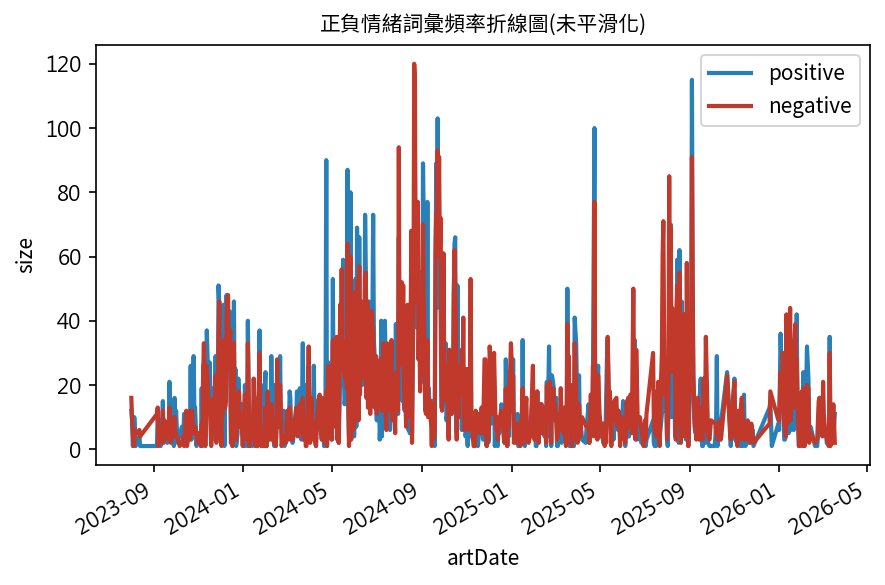

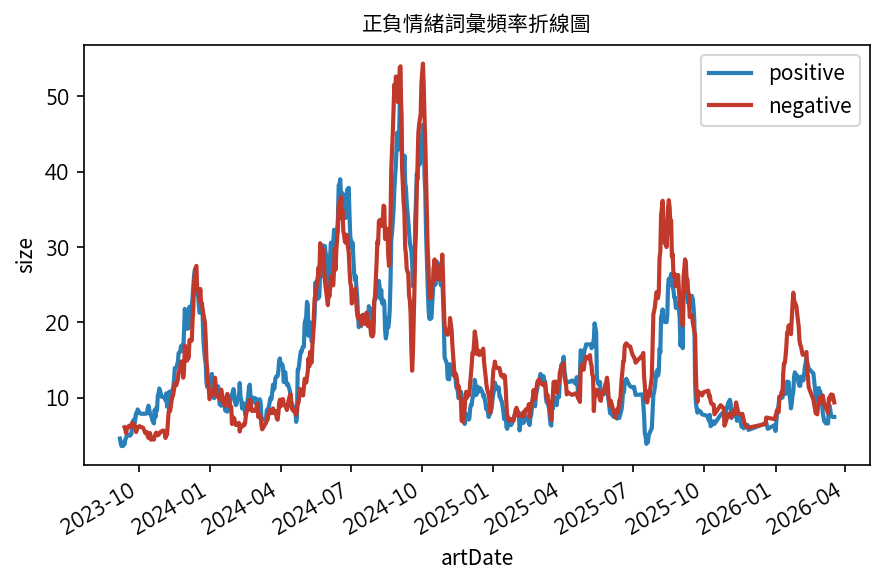

In [149]:
pos = sentiment_count[sentiment_count["sentiments"] == "positive"] # 取出正面情緒的資料
neg = sentiment_count[sentiment_count["sentiments"] == "negative"] # 取出負面情緒的資料

plot_sentiment_trend(pos, neg, "正負情緒詞彙頻率折線圖(未平滑化)")

# 使用 Series.rolling().mean() 來產生 14 天平均
rolling_days = 14

plot_sentiment_trend(pos, neg, "正負情緒詞彙頻率折線圖", meanDay=rolling_days)


於2024年7月後負面聲量數量開始略高於正面聲量


### 正負情緒詞彙比例折線圖

In [150]:
# 計算每一天正面和負面詞彙的比例（正面或負面詞彙數量 / 當天所有詞彙數量）

sentiment_ratio = sentiment_count.assign(
    ratio=sentiment_count.groupby("artDate")["size"].transform(lambda n: n / n.sum())
)
sentiment_ratio.head(10)

,artDate,sentiments,size,ratio
2,2023-08-01,negative,16,0.571429
3,2023-08-01,positive,12,0.428571
8,2023-08-02,negative,9,0.500000
9,2023-08-02,positive,9,0.500000
12,2023-08-03,positive,1,1.000000
14,2023-08-04,negative,1,0.333333
15,2023-08-04,positive,2,0.666667
17,2023-08-05,negative,2,0.166667
18,2023-08-05,positive,10,0.833333
23,2023-08-06,positive,6,0.500000


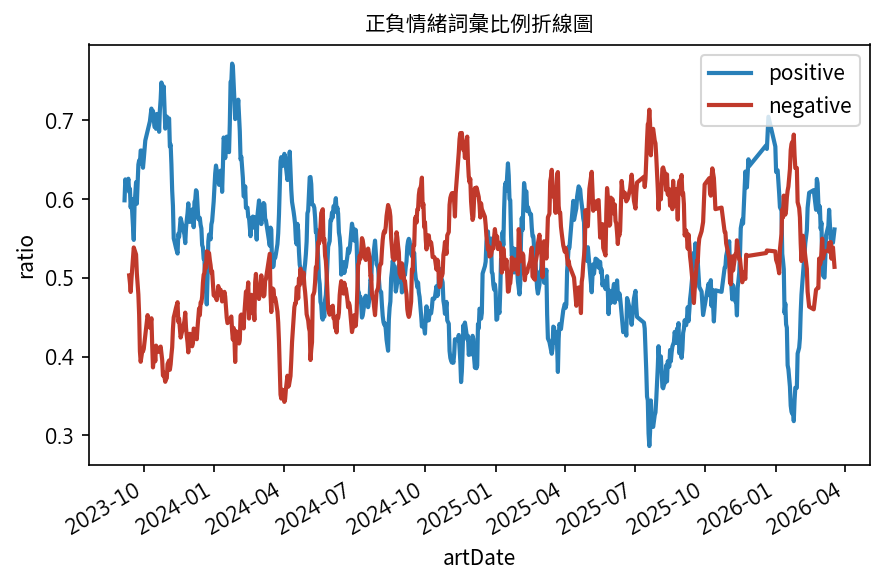

In [151]:
# 取出正面和負面情緒的比例資料
pos_ratio = sentiment_ratio[sentiment_ratio["sentiments"] == "positive"]
neg_ratio = sentiment_ratio[sentiment_ratio["sentiments"] == "negative"]

plot_sentiment_ratio(pos_ratio, neg_ratio, "正負情緒詞彙比例折線圖", meanDay=rolling_days)

透過比例折線圖可以更清楚看到正負面聲量分別在2024年7月、2025年7月、2026年1月，發生過三次交叉

初期的高峰與紅利期 (2023 下半年)：
新青安政策剛推行時，藍線 (Positive) 處於絕對高位（約 0.7），代表初期鄉民對於「低利率、高寬限期」普遍持樂觀態度，認為是購屋族的一大福音。

情緒的死亡交叉與震盪 (2024 年底 - 2025 年)：
隨著房價持續推升、銀行房貸滿水位等議題發酵，紅線 (Negative) 開始頻繁與藍線交錯，甚至多次超越藍線。這反映出鄉民討論重心轉向「房價飆漲、投資客鑽漏洞」等負面爭議，社群風向從期待轉為焦慮與不滿。

極端波動的近期表現 (2026 年)：
圖表末端出現劇烈的上下震盪，這通常代表市場處於極度敏感期。每一波政策微調或新聞報導都會引起鄉民激烈的正負對立，情緒切換非常迅速。

### 正負向情緒分數折線圖

In [152]:
# 先看一下原始資料
sentiment_ratio.head(10)

,artDate,sentiments,size,ratio
2,2023-08-01,negative,16,0.571429
3,2023-08-01,positive,12,0.428571
8,2023-08-02,negative,9,0.500000
9,2023-08-02,positive,9,0.500000
12,2023-08-03,positive,1,1.000000
14,2023-08-04,negative,1,0.333333
15,2023-08-04,positive,2,0.666667
17,2023-08-05,negative,2,0.166667
18,2023-08-05,positive,10,0.833333
23,2023-08-06,positive,6,0.500000


In [153]:
# 把資料從長格式轉換成寬格式，讓正面和負面情緒的比例可以在同一列呈現，方便後續分析和繪圖

sentiment_value = (
    sentiment_ratio.pivot_table(
        index="artDate", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)
sentiment_value.head()

,artDate,negative,positive
0,2023-08-01,16.0,12.0
1,2023-08-02,9.0,9.0
2,2023-08-03,0.0,1.0
3,2023-08-04,1.0,2.0
4,2023-08-05,2.0,10.0


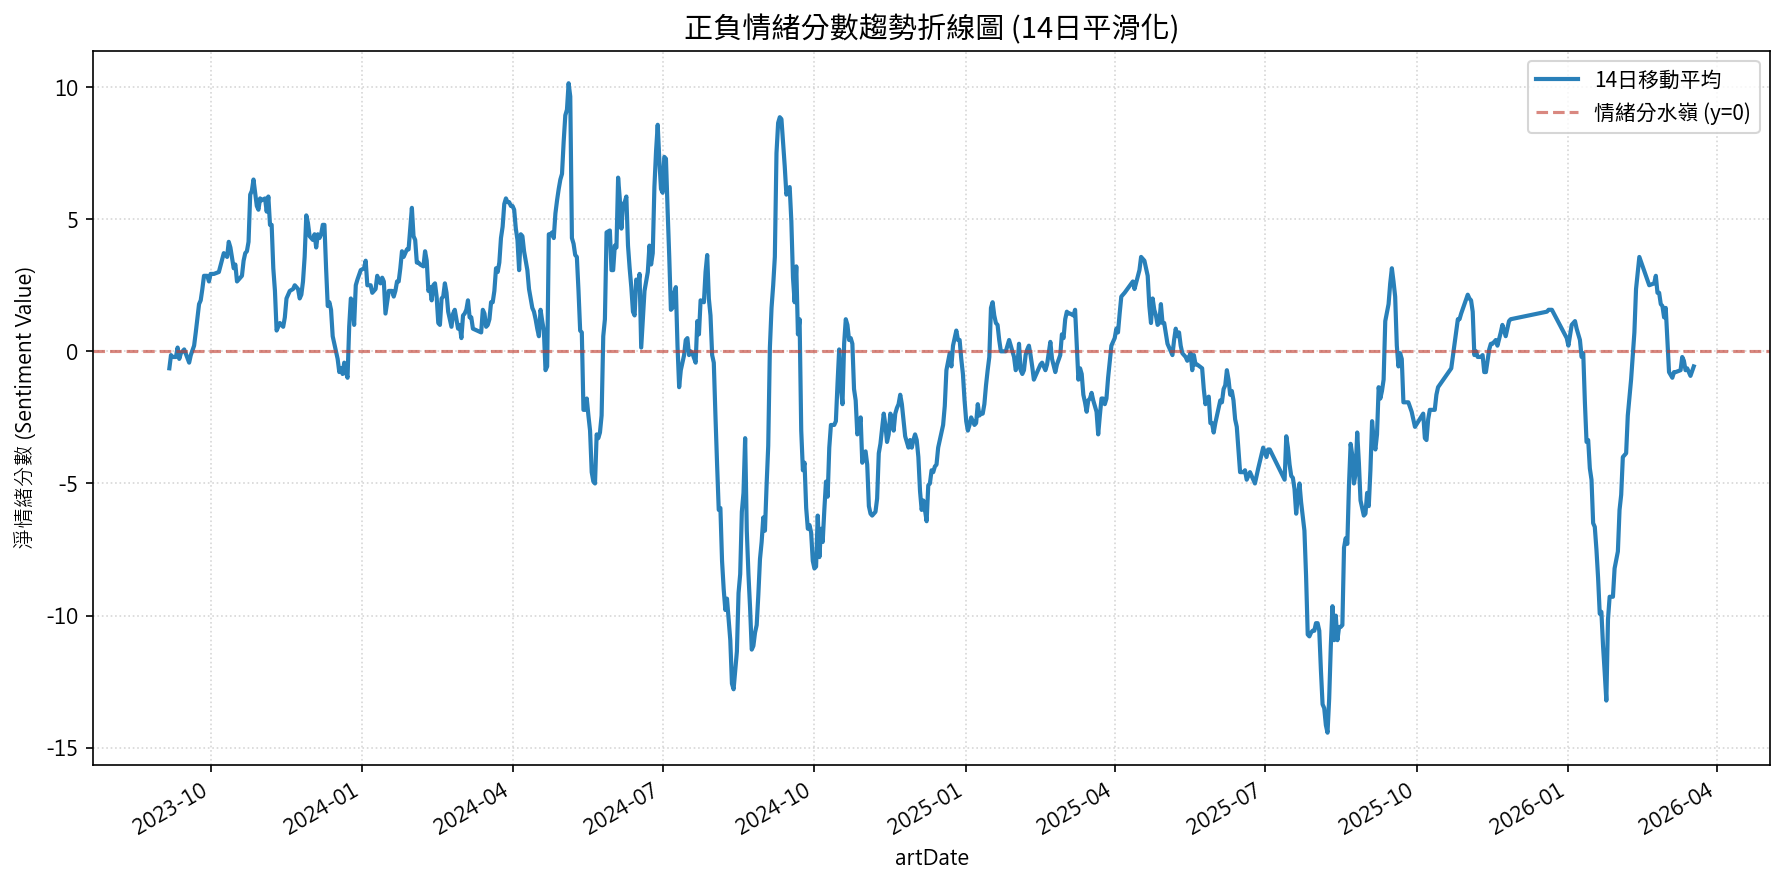

In [154]:
sentiment_value["sentiment_value"] = (
    sentiment_value["positive"] - sentiment_value["negative"]
)

plot_sentiment_net_trend(sentiment_value)

政策甜蜜期 (2023 下半年 - 2024 年中)：
兩張圖高度吻合。當正向比例領先時，淨情緒分數也維持在 5 到 15 分的高位。這顯示當時社群不僅「風向一致（比例高）」，且「力道強勁（分數高）」，反映了早期對政策紅利的集體認同。

風向轉折與負面爆發 (2024 年底)：
這是最精彩的對應點。比例圖出現「死亡交叉」時，淨分數圖同步發生斷崖式下跌（跌破 -5 甚至直衝 -10）。這代表討論焦點從「利息補貼」轉向「房價失控」與「銀行限貸」，負面情緒不僅變多，且力道極其劇烈。

極端情緒震盪 (2025 下半年 - 2026 年初)：
近期圖表呈現巨大的「V 型」與「倒 V 型」波動。這說明 PTT 的討論已進入高度極化階段：只要有新政策或爭議，分數就會瞬間暴跌到 -10 以下（極端不滿），或是快速回升。社群對新青安的評價已從早期的理性討論，轉向情緒性的焦慮與高度對立。

## 3.3 正負文章趨勢分析

In [155]:
# 改按照文章和情緒分類，計算每篇文章中正面和負面詞彙的數量

sentiment_count_by_article = pd.DataFrame(
    liwc_df.groupby(["artUrl", "sentiments"]).size()
).reset_index()
sentiment_count_by_article = sentiment_count_by_article.rename(columns={0: "size"})
sentiment_count_by_article.head(10)

,artUrl,sentiments,size
0,https://www.ptt.cc/bbs/HatePolitics/M.16911622...,affect,3
1,https://www.ptt.cc/bbs/HatePolitics/M.16911622...,negative,1
2,https://www.ptt.cc/bbs/HatePolitics/M.16911622...,positive,2
3,https://www.ptt.cc/bbs/HatePolitics/M.16980613...,affect,17
4,https://www.ptt.cc/bbs/HatePolitics/M.16980613...,anger,1
5,https://www.ptt.cc/bbs/HatePolitics/M.16980613...,anx,1
6,https://www.ptt.cc/bbs/HatePolitics/M.16980613...,negative,6
7,https://www.ptt.cc/bbs/HatePolitics/M.16980613...,positive,9
8,https://www.ptt.cc/bbs/HatePolitics/M.16983226...,affect,11
9,https://www.ptt.cc/bbs/HatePolitics/M.16983226...,negative,3


In [156]:
sentiment_value_by_article = (
    sentiment_count_by_article.pivot_table(
        index="artUrl", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

sentiment_value_by_article["sentiment_value"] = (
    sentiment_value_by_article["positive"] - sentiment_value_by_article["negative"]
)

sentiment_value_by_article['sentiment_class'] = sentiment_value_by_article['sentiment_value'].apply(lambda x: "正向" if x > 0 else "負向" )

sentiment_value_by_article.head()

,artUrl,affect,anger,anx,negative,positive,sad,sentiment_value,sentiment_class
0,https://www.ptt.cc/bbs/HatePolitics/M.16911622...,3.0,0.0,0.0,1.0,2.0,0.0,1.0,正向
1,https://www.ptt.cc/bbs/HatePolitics/M.16980613...,17.0,1.0,1.0,6.0,9.0,0.0,3.0,正向
2,https://www.ptt.cc/bbs/HatePolitics/M.16983226...,11.0,0.0,0.0,3.0,8.0,0.0,5.0,正向
3,https://www.ptt.cc/bbs/HatePolitics/M.16987300...,11.0,3.0,0.0,5.0,5.0,2.0,0.0,負向
4,https://www.ptt.cc/bbs/HatePolitics/M.16993200...,14.0,0.0,0.0,7.0,6.0,2.0,-1.0,負向


In [157]:
# 把每篇文章的情緒分數（正面詞彙數量 - 負面詞彙數量）轉換成情緒類別（正向或負向），然後與原始資料合併，得到每篇文章的情緒類別
clear_df_sentiment = pd.merge(clean_df, sentiment_value_by_article[['artUrl', 'sentiment_class']], how="left") # 原本是用原始 df 來 join

# 確保 artDate 是 datetime 格式，並且只保留日期部分（去掉時間）
# 原本的格式為 2023-08-01 18:52:50
clear_df_sentiment["artDate"] = pd.to_datetime(clear_df_sentiment["artDate"])
clear_df_sentiment['artDate'] = clear_df_sentiment['artDate'].dt.date

clear_df_sentiment.head()

,artTitle,artDate,artContent,artUrl,sentence,sentiment_class
0,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01,連結：\nhttps://money.udn.com/money/story/5621/73...,https://www.ptt.cc/bbs/home-sale/M.1690887173....,連結：， 記者游智文／即時報導。新版青年安心成家優惠房貸專案今(1)日上路，元宏不動產加值服...,負向
1,[新聞]台中7月房市衰退4都之最這1區幾乎腰斬,2023-08-01,https://udn.com/news/story/7325/7339682\n台中7月房...,https://www.ptt.cc/bbs/home-sale/M.1690891513....,這1區幾乎腰斬。聯合報／ 記者 趙容萱。六都公布今年7月買賣移轉棟數，除桃園月「開紅盤」增...,負向
2,[新聞]房市低迷台南7月買賣移轉棟數五年來最冷,2023-08-01,連結：\nhttps://house.udn.com/house/story/5889/73...,https://www.ptt.cc/bbs/home-sale/M.1690904337....,連結：， 台南7月買賣移轉棟數五年來最冷。2023-08-01 17:31:39 經濟日報...,NaN
3,[新聞]減輕年輕人買房負擔！青安貸款升級版今上,2023-08-01,減輕年輕人買房負擔！青安貸款升級版今上路 賴清德一張圖報你知\n\n連結：\nhttps:/...,https://www.ptt.cc/bbs/home-sale/M.1690905091....,減輕年輕人買房負擔！青安貸款升級版今上路 賴清德一張圖報你知。連結：， 2.0、實價登錄 2...,負向
4,Re:[閒聊]85年次以後的年輕工程師有多慘？,2023-08-02,原文恕刪\n背景交代一下\n小弟正好85年次\n前年台大非電資科系碩班畢業\n上山非產線常日...,https://www.ptt.cc/bbs/home-sale/M.1690910883....,原文恕刪，背景交代一下，小弟正好85年次，前年台大非電資科系碩班畢業，上山非產線常日班 目前...,正向


In [158]:
# TODO : 這裡可以把情緒類別為 NaN 的資料先過濾出來，看看有哪些文章沒有被分類到正向或負向，然後再決定要怎麼處理這些資料（例如丟掉、人工標註、或是用其他方法補齊）
# 顯示 clear_df_sentiment 中 sentiment_class 為 Nan 的資料
nan_sentiment_class = clear_df_sentiment[clear_df_sentiment['sentiment_class'].isna()]
print(len(nan_sentiment_class))
nan_sentiment_class.head()

509


,artTitle,artDate,artContent,artUrl,sentence,sentiment_class
2,[新聞]房市低迷台南7月買賣移轉棟數五年來最冷,2023-08-01,連結：\nhttps://house.udn.com/house/story/5889/73...,https://www.ptt.cc/bbs/home-sale/M.1690904337....,連結：， 台南7月買賣移轉棟數五年來最冷。2023-08-01 17:31:39 經濟日報...,NaN
14,Re:[新聞]租屋8月竟被「真屋主」驅離 牙醫家當遭,2023-08-11,話說學弟啊\n要不要來南崁這邊上班\n來這邊上班，不用租屋\n信貸一筆當頭期款+新青安就可以...,https://www.ptt.cc/bbs/home-sale/M.1691768932....,話說學弟啊，要不要來南崁這邊上班，來這邊上班，不用租屋，信貸一筆當頭期款+新青安就可以買一間...,NaN
26,[請益]以投資來考慮換房請益,2023-09-06,單身身上一間竹北800萬貸款兩房 現在賣掉大概1660左右\n剛好明年寬限期三年要到了\n想...,https://www.ptt.cc/bbs/home-sale/M.1693998833....,單身身上一間竹北800萬貸款兩房 現在賣掉大概1660左右，剛好明年寬限期三年要到了，想詢問...,NaN
29,[閒聊]菜蟲政府推新青安之後房價越漲越高,2023-09-08,https://i.imgur.com/ktCjHMF.jpg\n騙人的吧，這一定是房蟲去做...,https://www.ptt.cc/bbs/home-sale/M.1694143054....,,NaN
36,[新聞]房市交易回穩？8月房地三稅目寫今年以來,2023-09-12,連結：\nhttps://udn.com/news/story/7243/7434923\n...,https://www.ptt.cc/bbs/home-sale/M.1694527595....,連結：， 20:30 經濟日報／ 記者翁至威／台北即時報導。財政部今（12）日公布8月土增稅...,NaN


In [159]:
# 按照日期和情緒類別分類，計算每一天正向和負向文章的數量

sentiment_count_article = pd.DataFrame(
    clear_df_sentiment.groupby(["artDate", "sentiment_class"]).size()
).reset_index()
sentiment_count_article = sentiment_count_article.rename(columns={0: "size"})
sentiment_count_article = sentiment_count_article.sort_values(["artDate"])

sentiment_count_article

,artDate,sentiment_class,size
0,2023-08-01,負向,3
1,2023-08-02,正向,1
2,2023-08-02,負向,1
3,2023-08-03,正向,1
4,2023-08-04,正向,1
...,...,...,...
1209,2026-03-14,正向,1
1210,2026-03-14,負向,1
1212,2026-03-16,負向,1
1211,2026-03-16,正向,1


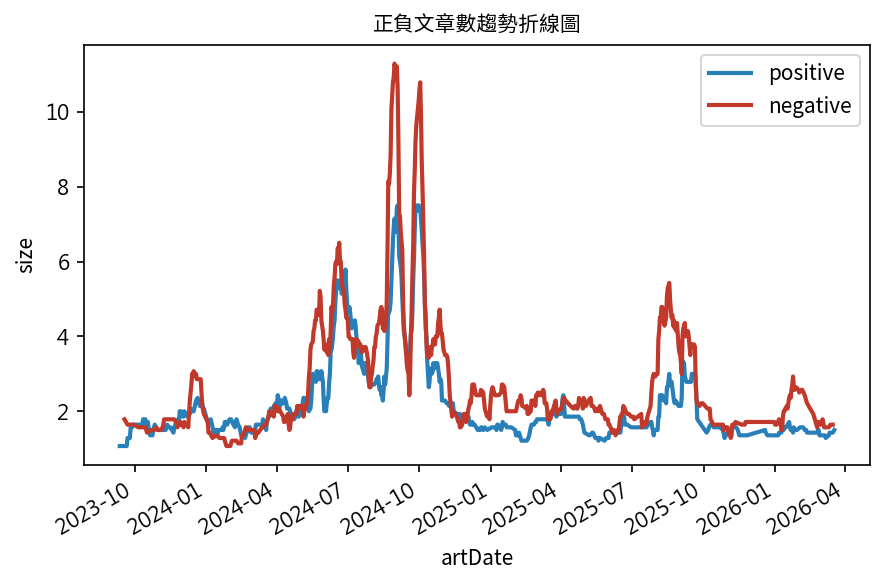

In [160]:
pos = sentiment_count_article[sentiment_count_article["sentiment_class"] == "正向"]
neg = sentiment_count_article[sentiment_count_article["sentiment_class"] == "負向"]

plot_sentiment_trend(pos, neg, "正負文章數趨勢折線圖", meanDay=rolling_days)

初期的「同溫層」現象 (2023 下半年)：
在前兩張圖中，2023 年的正向比例非常高，但在這張圖裡，當時的文章總數其實很低。

解讀： 這說明政策剛推出時，雖然討論的人不多（廣度小），但有發文的人大多抱持肯定態度（純度高）。這是一個典型的「利多初期」表現。


聲量與情緒的共振 (2024 年底爆發期)：
這是整份報告關鍵的對應點。可以發現 2024 年底，不僅負面詞頻比例飆高、淨分數跌到谷底，連文章數也衝到了最高點（接近 11 篇/日）。

這代表當時新青安並非少數人在吵架，而是引發了全版面的集體憤怒。高文章數 + 極端負面分數 = 大規模的負面輿論風暴（待確認當時的新聞狀況，可能是銀行限貸相關）。


後期的「零星交火」 (2025 年後半 - 2026 年)：
文章數數量不多，但詞頻比例卻震盪劇烈。

解讀： 這顯示該話題在 PTT 已進入「日常化」。發文量雖不多，但只要有一篇新政策新聞，底下的推文就會引發極端的情緒對立（分數劇烈跳動）。

與正負情緒詞彙頻率折線圖相比，正負向曲線之間的距離增加，負向更高於正面，代表負面文章的數量增加的幅度比正面文章更大，這可能是因為在某些事件或議題上，負面情緒的表達更為強烈或普遍。

## 3.4 正負情緒關鍵字

### 取得情緒關鍵字

In [161]:

# 一詞多標籤

word_count = liwc_df.groupby(["word", "sentiments"]).size().reset_index()
word_count = word_count.rename(columns={0: "size"})
word_count = word_count.sort_values(["size"], ascending=False)

word_count.head(10)

,word,sentiments,size
490,問題,affect,1379
491,問題,negative,1379
2067,負擔,affect,580
2068,負擔,negative,580
2256,風險,negative,487
2254,風險,affect,487
2255,風險,anx,487
2039,謝謝,affect,454
2040,謝謝,positive,454
761,幫助,affect,420


In [162]:
# 取得正負面關鍵字
word_of_pos = word_count.loc[(word_count["sentiments"] == "positive")]
word_of_neg = word_count.loc[(word_count["sentiments"] == "negative")]

print(word_of_pos.head(15))
print(word_of_neg.head(15))

     word sentiments  size
2040   謝謝   positive   454
762    幫助   positive   420
760    希望   positive   394
235    優惠   positive   369
1163   支持   positive   282
1259   朋友   positive   241
285    分享   positive   227
2250   願意   positive   219
1374   決定   positive   213
712    容易   positive   209
501    喜歡   positive   208
2327   鼓勵   positive   193
437    合理   positive   187
1985   解決   positive   185
177    信義   positive   180
     word sentiments  size
491    問題   negative  1379
2068   負擔   negative   580
2256   風險   negative   487
581    壓力   negative   414
1676   白痴   negative   411
2209   降低   negative   271
1152   擔心   negative   258
2080   貪婪   negative   247
32     不宜   negative   219
68     不足   negative   180
2151   違約   negative   155
1062   抑制   negative   151
544    嚴重   negative   149
1719   禁止   negative   133
2216   隨便   negative   131


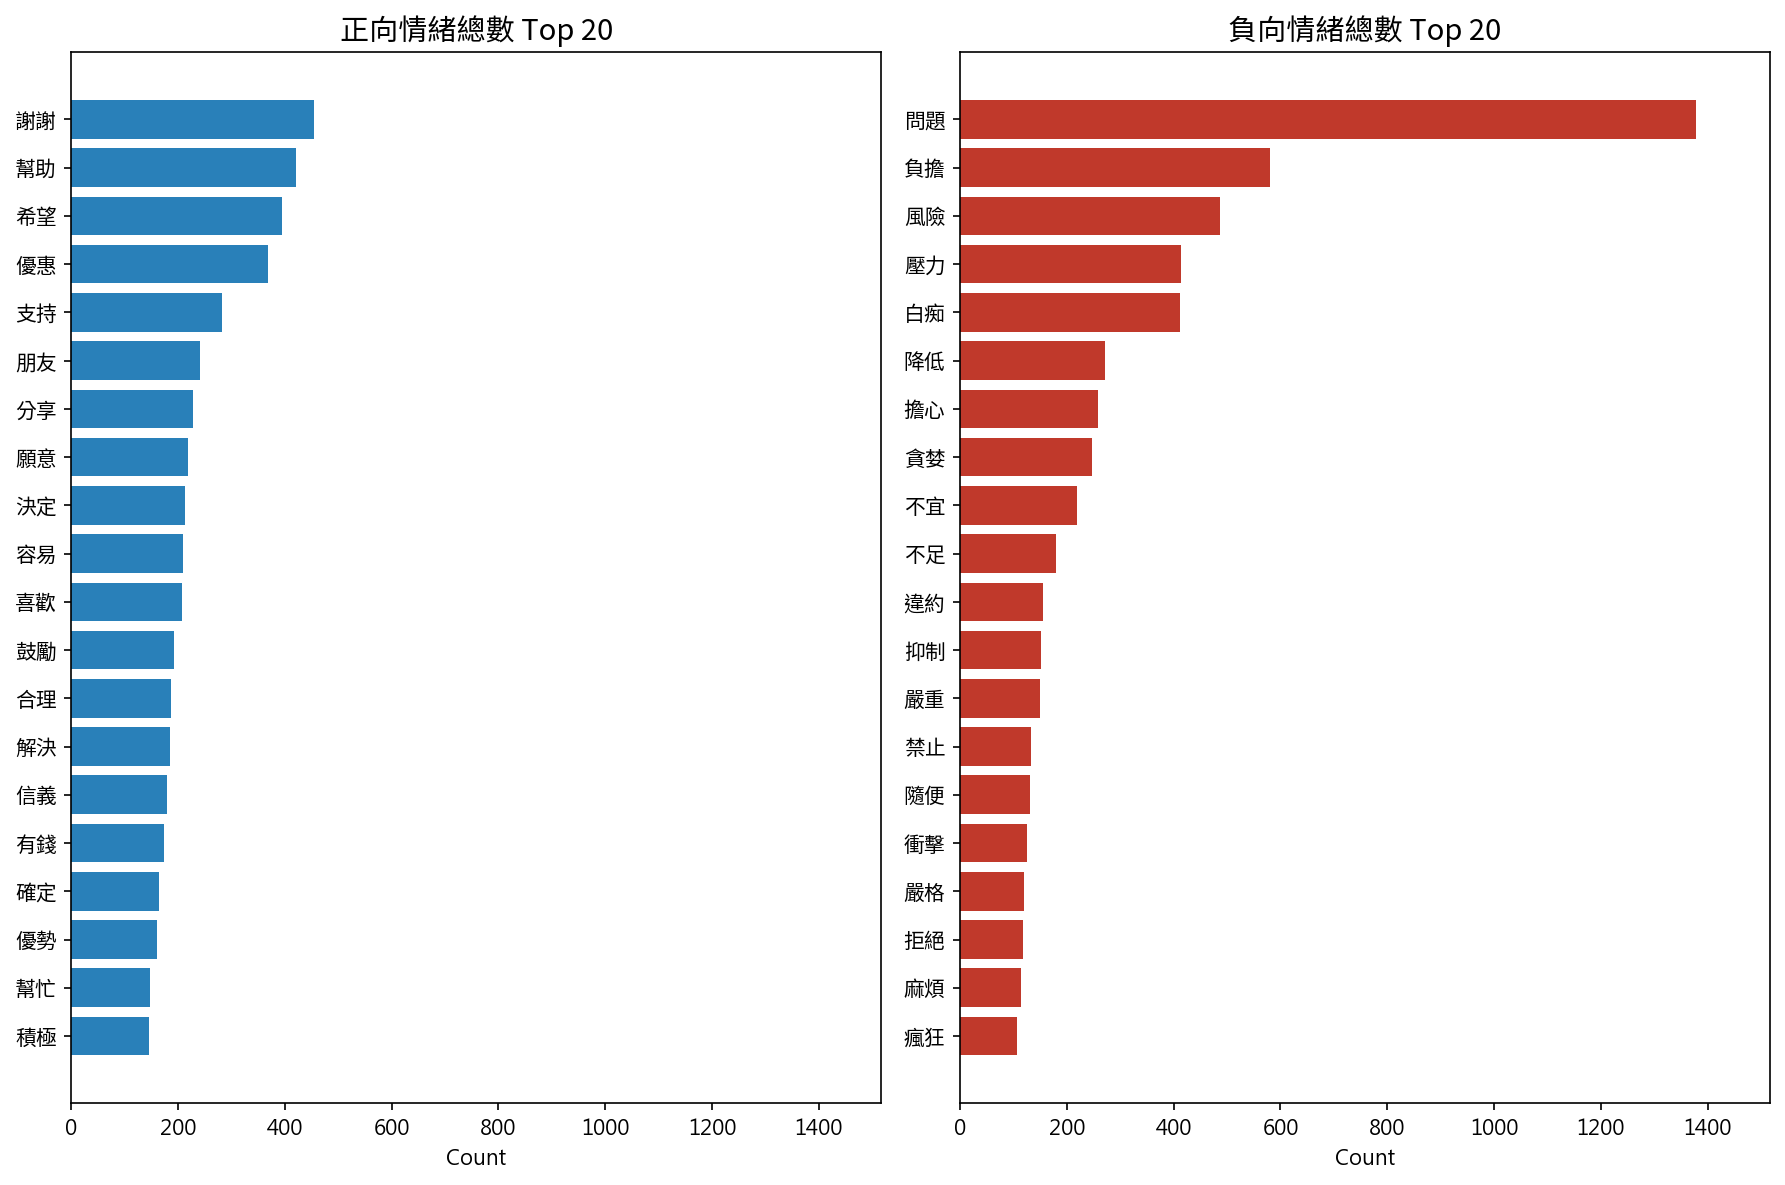

In [163]:
# 初始關鍵字(未經調整)

obs = 20

pos = word_of_pos.head(obs).sort_values(["size"], ascending=True)
neg = word_of_neg.head(obs).sort_values(["size"], ascending=True)

plot_sentiment_word_bar(pos, neg)

In [164]:
filtered_df = sentence_df[sentence_df['sentence'].str.contains('支持', na=False)]

for sentence in filtered_df['sentence'].to_list():
    print(sentence)
    print("=========================")

支持首購族買房
支持青年購屋
政府為了支持青年購屋
只支持有腦袋處理的
1.請蔡總統積極促成行政院與執政黨立委支持「實價登錄2.0」
3.請立院朝野各黨委員支持「實價登錄2.0」法案
這樣支持房子不能漲
間 身體力行支持自己言論的
貸款資源要留給小資年輕人   新青安房貸就是個好政策    我也蠻支持之前侯提出的全
除了感謝全體會員們這3年來的支持
不少人支持
這樣的方案您各位支持嗎
安政策目標就是支持年輕人買房
支持
也感謝另一半的支持
很幸運一路上貴人支持
更何況當初這個政策的推出獲得朝野一致支持
除了首購受到政策支持外
個人一向支持健全的房市跟租屋市場
確實支持無
顯示該政策確實支持無自有住宅的青年購屋自住需求
才是支持居住正義的一方
讓支持自住民眾購屋
用支持韓國瑜 反年改 去換居住正義法案呀
新青安仍是政府支持青年住者有其屋的良善美
之前是支持買股不買房
都需要預算和立院的支持
這個完全支持政府嚴格取締
考量綠營40歲以上的支持度鐵打不破
20歲左右的支持度才是和民眾黨的勝負關鍵
開始覺得你以為政府支持青年的想法很愚蠢了吧
支持政府讓白眼狼斷頭
基本上支持現在嚴格審查新青安
可能與總價700至1500萬元的族群需要相當的銀行房貸支持有關
民進黨團勢必得尋求在野黨立委的支持
銀行必須予以支持
他們表示支持
居住正義唯一支持時代力量好嗎
支持建商跟多屋投資族
先不論金龍哥這個判斷背後是否有真實數據支持
個人支持打炒房
對這次的政策也支持
建議房仲業者應積極拓展受政府支持的相關副業
「嗯嗯~~感謝您的支持~^^
那就是又大力支持又創造gdp又政治獻金又敢敢購地又綁住就業率的綠油油建商們
那多多空空就一起支持嘛
去支持他們的信心
我個人是支持自住買房的
積極推動「百萬戶租屋家庭支持計畫」興辦社會住宅、擴大租金補貼專案
內政部目前也積極推動「百萬戶租屋家庭支持計畫」興辦社會住宅、擴大租金
支持買房
這樣的變化正在扼殺家庭的支持性和個
為個體提供強烈的支持、情感、安全
是社安網中非常重要的非正式社會支持體系
家庭作為情感支持跟社會救助的防線也會跟著崩潰
產業發展往往仰賴穩定的資金支持
的支持
支持房價持續上漲；不過
還好原po父母願意提供支持
請支持『中產以下買房節育最佳解』謝謝
這樣還不夠支持嗎
我支持繼續緊縮拉
甚至買的時候親人都極力反對 只有我老婆支持
那有沒有

## 3.5 重新計算情緒

In [165]:
# 設定要移除的字詞列表
words_to_remove = ['負擔', '風險','降低','負債', '優惠', '謝謝', '朋友', '分享', '信義','問題', '有錢', '隨便', '驚人', '離婚'] # 禁止 隨便 鼓勵 問題

# 修訂字典，使用 ~ 運算子和 isin() 方法過濾掉包含在 words_to_remove 列表中的行
liwc_dict_revise = liwc_dict[~liwc_dict['word'].isin(words_to_remove)]

# 使用更新後的情緒字典 merge
liwc_df_revise = pd.merge(token_df[["artUrl", "artDate", "artTitle", "artContent","word"]], liwc_dict_revise, how="left")

# 移除英文詞
liwc_df_revise = liwc_df_revise[
    ~liwc_df_revise['word'].str.contains(r'[A-Za-z]', na=False)
]

# liwc_df_revise 的 artDate 只保留到日期
liwc_df_revise['artDate'] = pd.to_datetime(liwc_df_revise['artDate']).dt.normalize()

liwc_df_revise.head()

,artUrl,artDate,artTitle,artContent,word,sentiments
0,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,游智文,NaN
1,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,即時,NaN
2,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,新版,NaN
3,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,青年安心成家,NaN
4,https://www.ptt.cc/bbs/home-sale/M.1690887173....,2023-08-01,[新聞]新青安房貸今上路建商救命浮木來了？,連結：\nhttps://money.udn.com/money/story/5621/73...,優惠,NaN


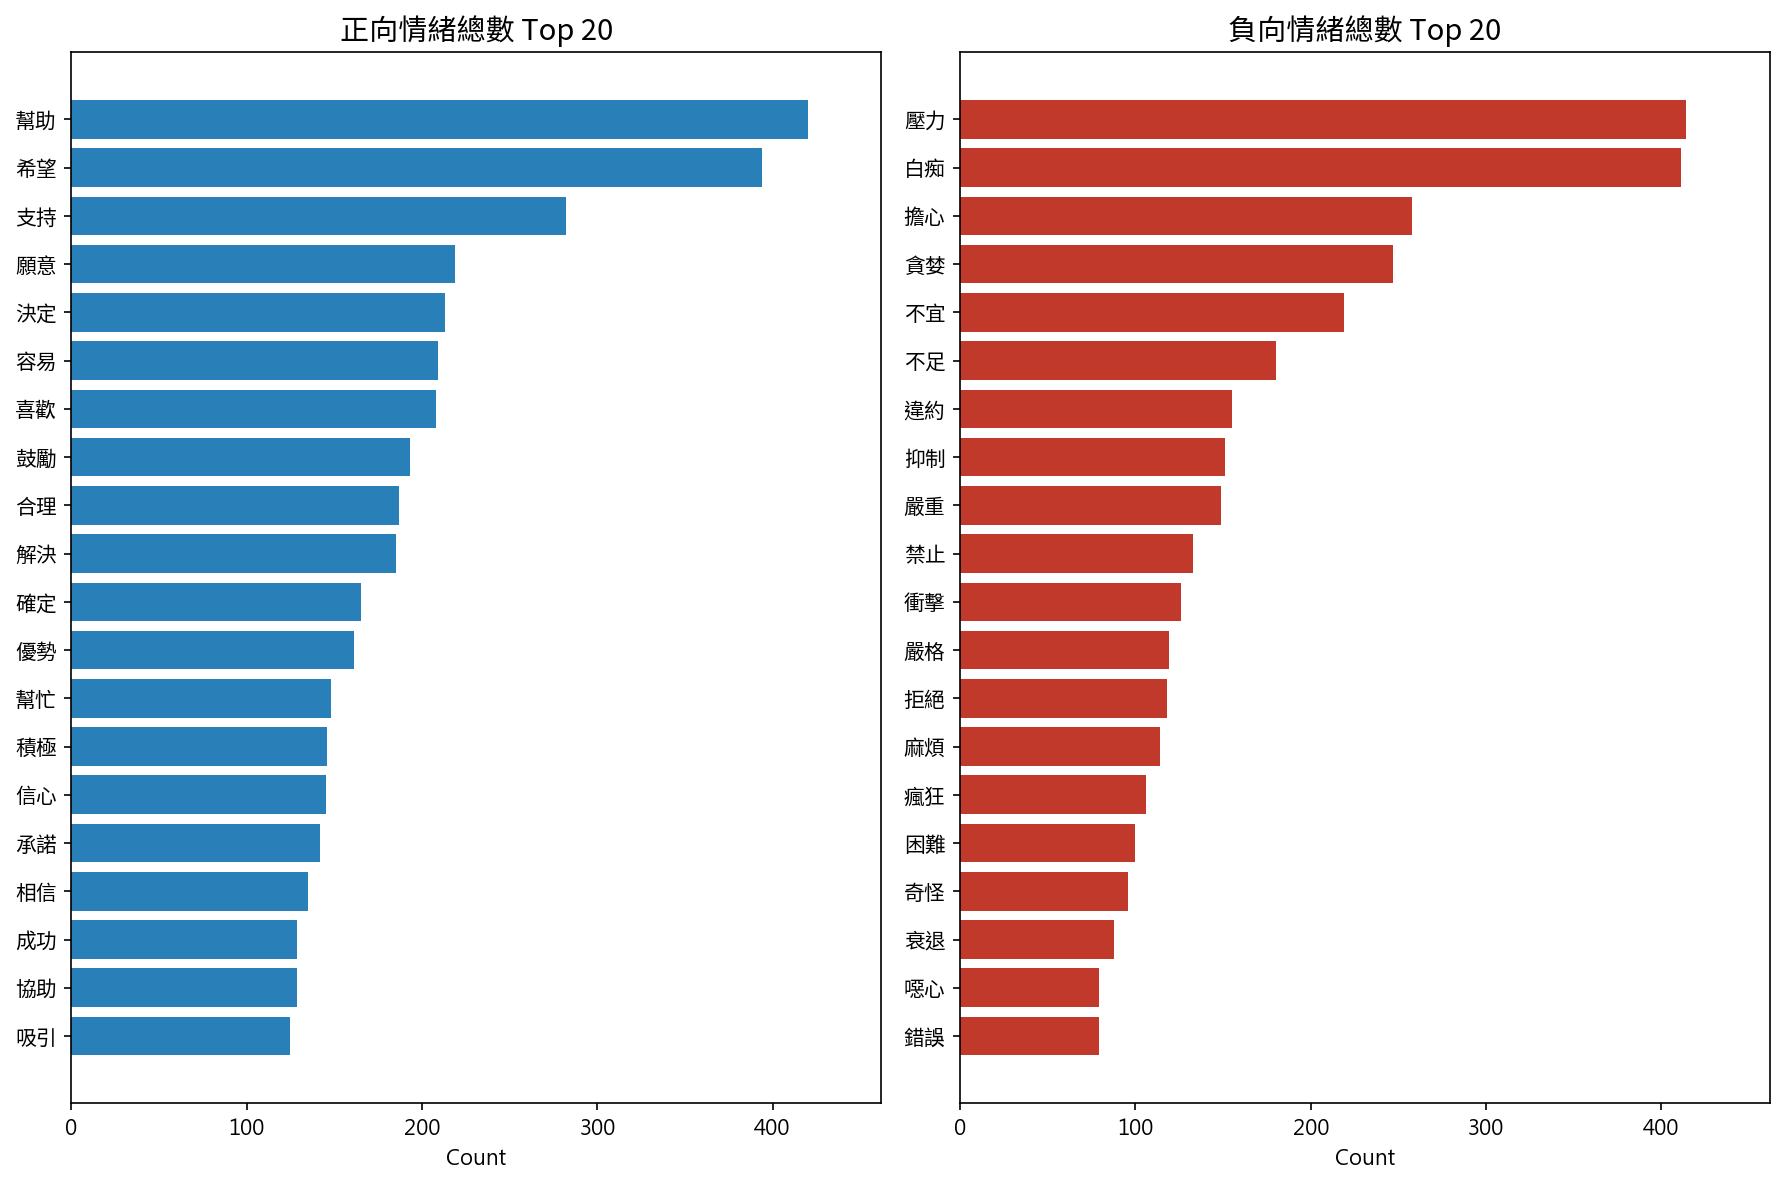

In [166]:
word_count_revise = liwc_df_revise.groupby(["word", "sentiments"]).size().reset_index()

word_count_revise = word_count_revise.rename(columns={0: "size"})
word_count_revise = word_count_revise.sort_values(["size"], ascending=False)

word_of_pos_revise = word_count_revise.loc[(word_count_revise["sentiments"] == "positive")]
word_of_neg_revise = word_count_revise.loc[(word_count_revise["sentiments"] == "negative")]

pos_revise = word_of_pos_revise.head(obs).sort_values(["size"], ascending=True)
neg_revise = word_of_neg_revise.head(obs).sort_values(["size"], ascending=True)

plot_sentiment_word_bar(word_of_pos_revise, word_of_neg_revise)

在資料視覺化（Data Visualization）中，「全域標度（Global Scaling）」是比較研究的底線。視覺誤導（Visual Misleading）： 若正向情緒與負面情緒的 X 軸單位不統一，會因「長度錯覺」而對議題的「對立強度」產生錯誤認知。在學術審查中，這常被質疑為「刻意放大局部特徵」以符合特定預設（如：預設負面聲量較大）。
數據與詮釋的脫鉤： 若基於「視覺長度」宣稱負面聲量壓倒正面，但底下的標數（Numbers）卻顯示兩者旗鼓相當，這會造成邏輯上的 「認知失調」，容易在問答環節被直接切入痛點。

「問題」的語境陷阱與敏感度分析
從學術嚴謹度來看，當一個高頻詞同時具備「實質負面（Problem）」與「功能中性（Question）」時，進行「敏感度分析（Sensitivity Analysis）」是非常必要的。

排除法（Exclusion）的意義： 既然無法透過簡單的詞頻（Unigram）區分語境，將其剔除後觀察「剩餘數據的分布」是合理的。如果剔除後正負向趨於 50/50，這說明該議題在 PTT 上的基本盤（Baseline）其實是中性的，之前的負面傾斜很可能是被這個「語境雜訊」所放大。

進階解法（N-gram）： 若要真正解決，通常需要看 Bigram（二連詞），例如「有問題」vs.「問問題」。但在目前的時程下，這屬於後續優化的範疇。

### 重新繪製情緒分數趨勢圖

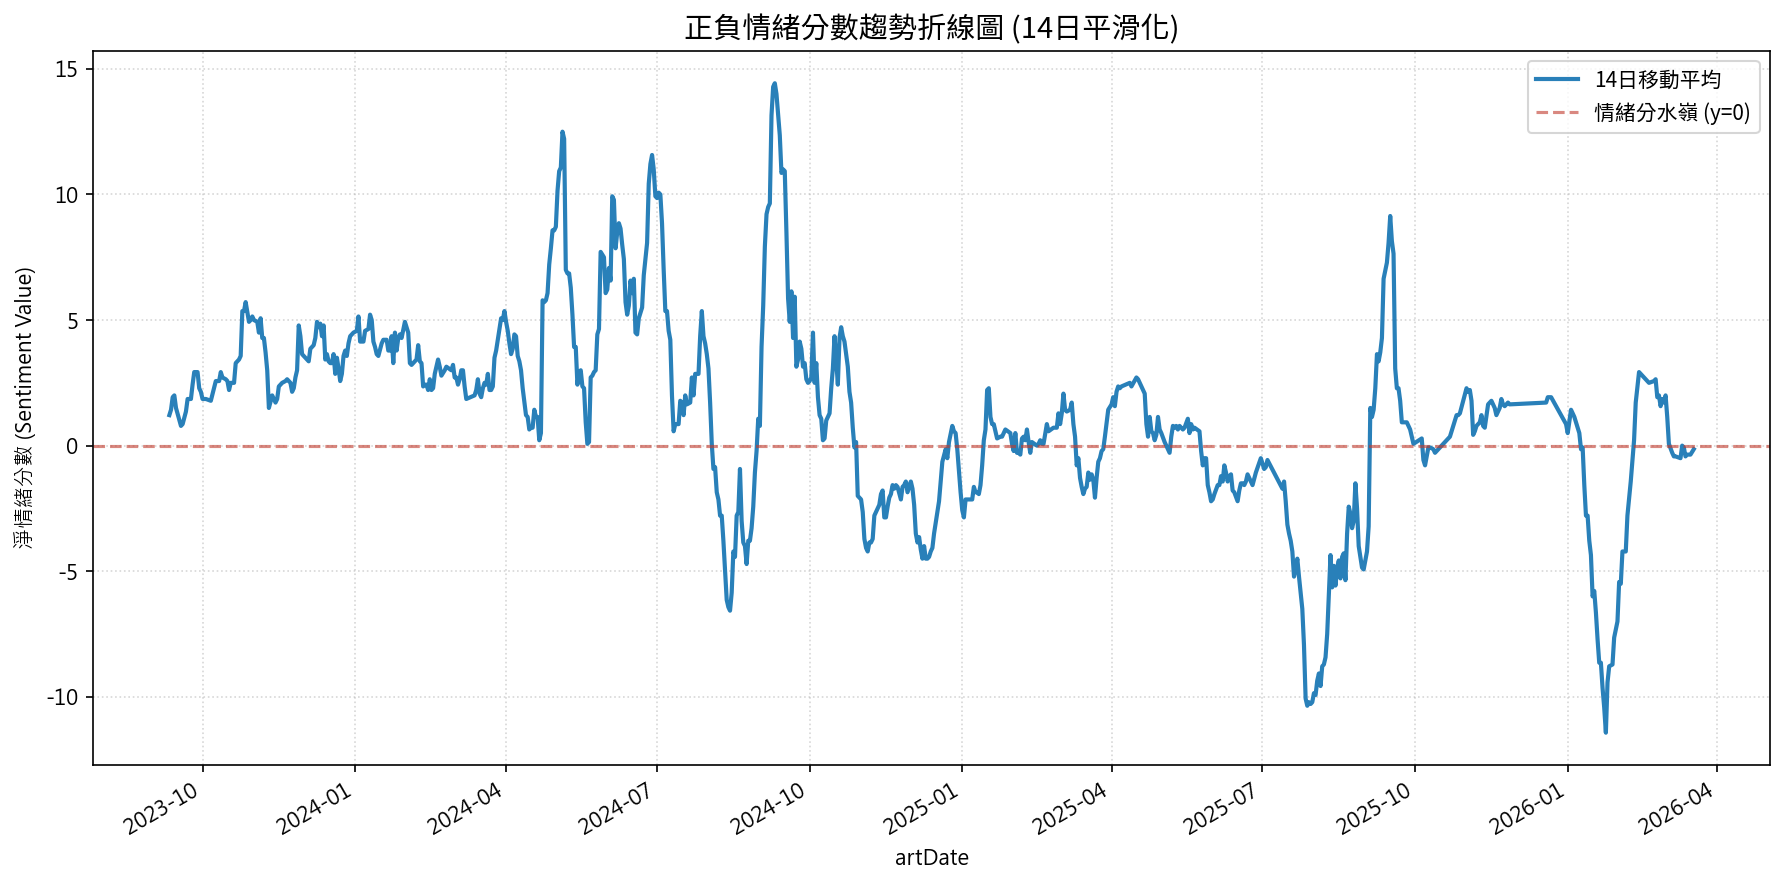

In [167]:
sentiment_count_revise = pd.DataFrame(
    liwc_df_revise.groupby(["artDate", "sentiments"]).size()
).reset_index()

mask = (sentiment_count_revise['sentiments'] == "positive") | (sentiment_count_revise['sentiments'] == "negative") 
sentiment_count_revise = sentiment_count_revise.loc[mask]

sentiment_count_revise = sentiment_count_revise.rename(columns={0: "size"})
sentiment_count_revise = sentiment_count_revise.sort_values(["artDate"])

sentiment_value_revise = (
    sentiment_count_revise.pivot_table(
        index="artDate", columns="sentiments", values="size", fill_value=0
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

sentiment_value_revise["sentiment_value"] = (
    sentiment_value_revise["positive"] - sentiment_value_revise["negative"]
)

plot_sentiment_net_trend(sentiment_value_revise, rolling_days=rolling_days)

可以比較修訂前跟修訂後的兩張折線圖，V字有略微減少

## 3.6 負面文章的文字雲

綜合上述圖表，將期間鎖定在 2024/7月~2025年1月 之間

In [168]:
# 取出時間內負面情緒的文章，看看有哪些詞彙出現

date = "2024-07-01"
end_date = "2025-01-01"

# 以詞彙為單位，取得所屬文章的情緒類別
liwc_df_revise = pd.merge(liwc_df_revise, sentiment_value_by_article[['artUrl', 'sentiment_class']], how="left")

mask = (liwc_df_revise['artDate'] >= pd.Timestamp(date)) & (
    liwc_df_revise['artDate'] <= pd.Timestamp(end_date)) & (
    liwc_df_revise['sentiment_class'] == "負向")

# 文字雲資料集，過濾出指定日期範圍內，且情緒類別為負向的詞彙，並保留文章日期和詞彙欄位
wc_df = liwc_df_revise.loc[mask, ["artDate", "word"]]

# 按照詞彙計算頻率，得到每個詞彙在負面情緒文章中出現的次數，並按照頻率排序
word_count_neg = pd.DataFrame(
    wc_df.groupby(["word"]).size()
).reset_index().rename(columns={0: "size"}).sort_values(by='size', ascending=False)

word_count_neg.head()

,word,size
6988,房貸,1828
14518,銀行,1200
12407,補貼,929
6943,房價,838
6253,建商,760


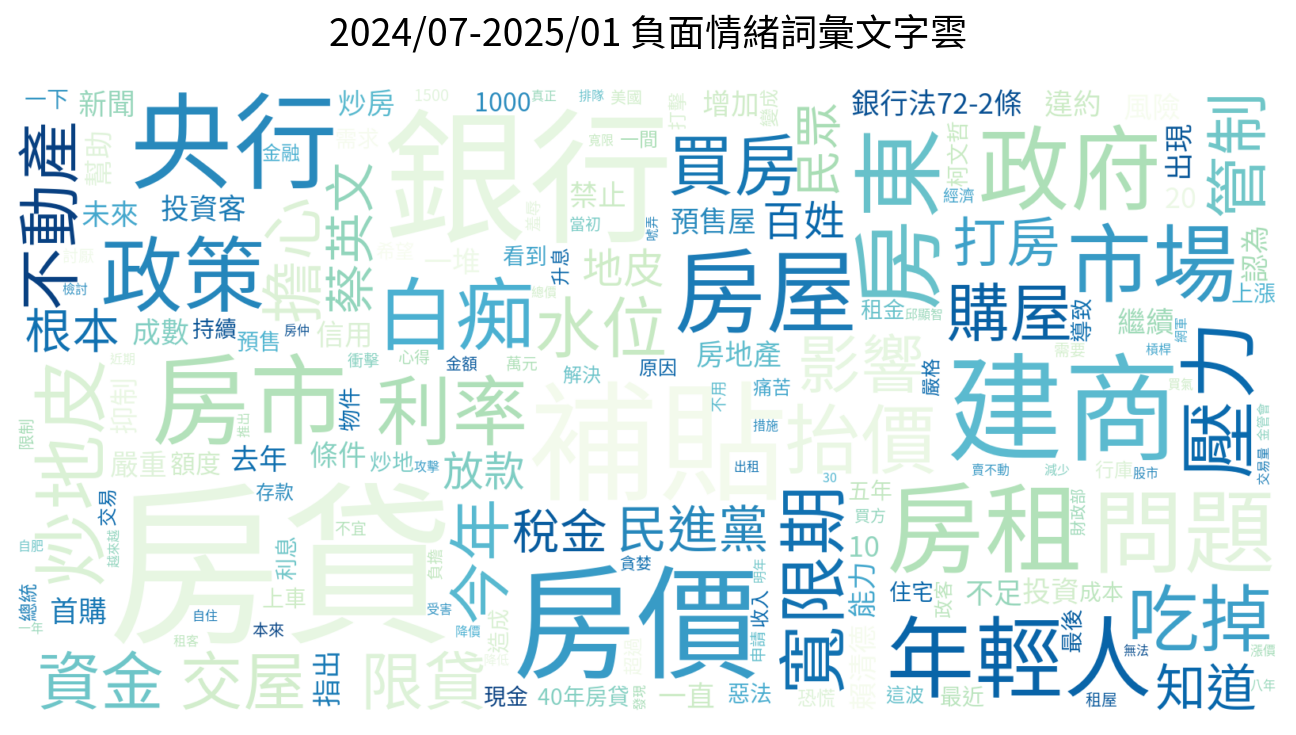

In [169]:
wc_dict = dict(zip(word_count_neg['word'], word_count_neg['size']))
plot_wordcloud(wc_dict, title="2024/07-2025/01 負面情緒詞彙文字雲", colormap='GnBu')

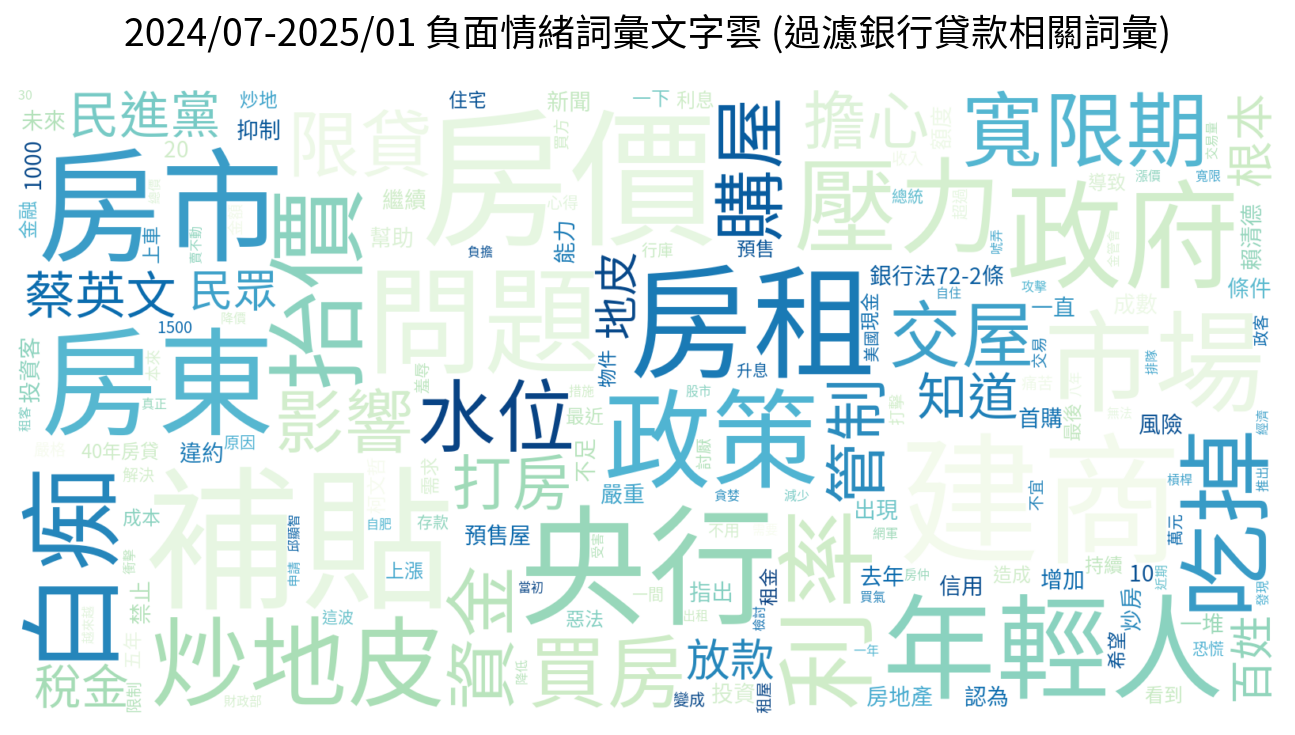

In [170]:
# wc_dict 排除掉 銀行、貸款、房屋、房子 等詞彙，因為這些詞彙雖然頻率高，但對於分析情緒趨勢沒有太大意義，反而會讓真正能反映情緒的詞彙被淹沒在雜訊中
words_to_exclude = ['銀行', '貸款', '房屋', '房子','房貸','台灣','今年','不動產','新青安']
wc_dict_filtered = {word: freq for word, freq in wc_dict.items() if word not in words_to_exclude}
plot_wordcloud(wc_dict_filtered, title="2024/07-2025/01 負面情緒詞彙文字雲 (過濾銀行貸款相關詞彙)", colormap='GnBu')

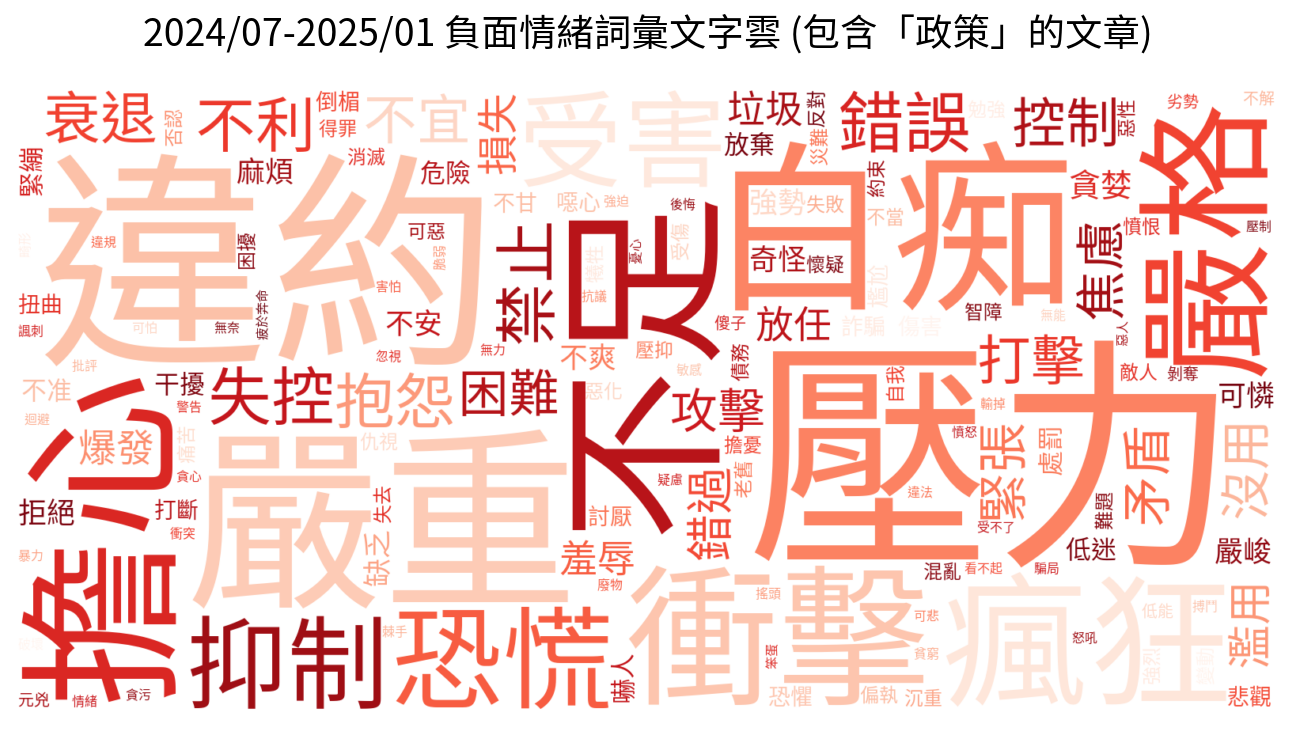

In [171]:
# 取得時間內，包含特定詞彙的負向文章其中的負面情緒詞彙
mask = (liwc_df_revise['artDate'] >= pd.Timestamp(date)) & (
    liwc_df_revise['artDate'] <= pd.Timestamp(end_date)) & ( 
    liwc_df_revise['sentiment_class'] == "負向")  & ( 
    liwc_df_revise['artContent'].str.contains('政策')) & (
    liwc_df_revise["sentiments"] == "negative") # 負面情緒字

wc_df_neg_word = liwc_df_revise.loc[mask, ["artDate", "word"]]
word_count_neg_word = wc_df_neg_word.groupby(["word"]).size().to_dict()

plot_wordcloud(word_count_neg_word, title="2024/07-2025/01 負面情緒詞彙文字雲 (包含「政策」的文章)", colormap='Reds')

# 4. 情緒分析 Part2

## 4.1 套件安裝

In [172]:
# 情緒分析二 專屬套件（CKIP + SnowNLP）
# 若尚未安裝請執行此格，之後可跳過
%pip install ckiptagger[tf,gdown] snownlp

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 套件說明 + 載入套件

In [27]:
# ============================================================
# 套件說明
# ============================================================
"""
- ckiptagger  : 中研院開發的中文自然語言處理工具（斷詞、詞性、NER）
- SnowNLP    : 中文情緒分析套件，輸出 0~1 情緒分數（0=負面, 1=正面）
"""

from ckiptagger import data_utils, construct_dictionary, WS, POS, NER
from snownlp import SnowNLP
import time
import datetime

# Windows 中文字體設定
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

print("✅ 套件載入完成")



✅ 套件載入完成


## 4.2 CKIP處理

### 下載 CKIP 模型資料 

In [ ]:
# ============================================================
# 安裝 CKIP 模型資料
# ============================================================
# 第一次執行需下載約 1.88GB 的模型檔，之後就不用再跑這格
# 下載完會在你的資料夾產生一個 data/ 目錄

data_utils.download_data_gdown("./")
print("✅ CKIP 模型下載完成")

Downloading...
From (original): https://drive.google.com/uc?id=1efHsY16pxK0lBD2gYCgCTnv1Swstq771
From (redirected): https://drive.google.com/uc?id=1efHsY16pxK0lBD2gYCgCTnv1Swstq771&confirm=t&uuid=d6454db0-ecd7-4a5d-b87a-7e7598e0a9ff
To: c:\Users\p6267\Desktop\中山大學課程\113_4_社群媒體分析\讀書會\第一次\data.zip
100%|██████████| 1.88G/1.88G [03:26<00:00, 9.08MB/s]


✅ CKIP 模型下載完成


### 載入 CKIP 模型

In [28]:
# ============================================================
# 利用 CKIP 進行自然語言處理
# ============================================================
# 將三份工具的模型路徑指向剛才下載的「data」資料夾

ws  = WS("./data")
pos = POS("./data")
ner = NER("./data")

print("✅ CKIP 模型載入完成")

c:\Users\p6267\AppData\Local\Programs\Python\Python312\Lib\site-packages\ckiptagger\model_ws.py:106: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)
c:\Users\p6267\AppData\Local\Programs\Python\Python312\Lib\site-packages\ckiptagger\model_pos.py:56: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)
c:\Users\p6267\AppData\Local\Programs\Python\Python312\Lib\site-packages\ckiptagger\model_ner.py:57: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by

✅ CKIP 模型載入完成


### 讀取資料(分析角度: 文章+推文留言進行全面性探討)

In [29]:
# ============================================================
# 讀取資料（篩選 home_sale 版)，分析角度: 文章+推文留言進行全面性探討
# ============================================================
import ast

# 只讀取有用的 11 個欄位，略過後面大量空欄
USECOLS = ['system_id', 'artComment', 'artTitle', 'artDate',
           'insertedDate', 'artContent', 'e_ip', 'artUrl',
           'dataSource', 'artCatagory', 'artPoster']

df_raw = pd.read_csv(
    "raw_data/Book_Club_Project_202308.csv",
    encoding="utf-8-sig",
    usecols=USECOLS
)

# 只保留 artCatagory == home_sale 的正確列（過濾掉跑版的髒資料）
df_art = df_raw[df_raw['artCatagory'] == 'home_sale'].copy().reset_index(drop=True)
print(f"✅ 文章筆數：{len(df_art)} 篇")

# ── 解析 artComment，把推文展開成獨立列 ──────────────────
def parse_comments(row):
    """把一篇文章的所有推文解析成 list of dict"""
    try:
        comments = ast.literal_eval(str(row['artComment']))
        result = []
        for c in comments:
            result.append({
                'system_id'  : row['system_id'],
                'artDate'    : row['artDate'],         # 繼承文章日期（推文日期也可用 cmtDate）
                'cmtStatus'  : c.get('cmtStatus', ''),
                'cmtPoster'  : c.get('cmtPoster', ''),
                'cmtContent' : c.get('cmtContent', '').lstrip(':').strip(),  # 去掉開頭的冒號
                'cmtDate'    : c.get('cmtDate', ''),
                'text_type'  : 'comment'               # 標記這是推文
            })
        return result
    except:
        return []

# 展開所有推文
comment_rows = []
for _, row in df_art.iterrows():
    comment_rows.extend(parse_comments(row))

df_comments = pd.DataFrame(comment_rows)
print(f"✅ 推文筆數：{len(df_comments)} 則")
print(f"\n推/噓/→ 分佈：")
print(df_comments['cmtStatus'].value_counts())

# ── 建立統一的分析用 df ──────────────────────────────────
# 文章本文
df_articles = df_art[['system_id', 'artDate', 'artContent']].copy()
df_articles['text_type'] = 'article'
df_articles.rename(columns={'artContent': 'text'}, inplace=True)

# 推文
df_comments_slim = df_comments[['system_id', 'artDate', 'cmtContent', 'cmtDate', 'cmtStatus', 'text_type']].copy()
df_comments_slim.rename(columns={'cmtContent': 'text'}, inplace=True)

print(f"\n✅ 合計分析文本：文章 {len(df_articles)} 篇 + 推文 {len(df_comments_slim)} 則")

# CKIP 標註用文章本文
df = df_art.copy()

✅ 文章筆數：2932 篇
✅ 推文筆數：185520 則

推/噓/→ 分佈：
cmtStatus
→    103970
推     71935
噓      9615
Name: count, dtype: int64

✅ 合計分析文本：文章 2932 篇 + 推文 185520 則


### 定義文字清理函式

In [30]:
# ============================================================
# 定義文字清理與斷句函式
# ============================================================

def Segmentation_Core(data, tokenizer):
    regexPattern = '|'.join(map(re.escape, tokenizer))
    output_list = re.split(regexPattern, data)
    output_list = list(filter(None, output_list))
    return output_list

def Sentence_Segmentation(article, keep_digits=True, keep_alphabets=False):
    """
    斷句步驟：
    1. 去除換行符號
    2. 去除特殊符號
    3. 依照句號、問號、驚嘆號等斷句
    """
    special_symbols = r'[.＂<>:《》+\-=#$%&()*@＃＄％＆＇\(\)\[\]\{\}（）＊＋－／：＜＝＞＠［＼］＾＿｀｛｜｝～｟｠｢｣､、〃》「」『』【】〔〕〖〗〘〙〚〛〜〝〞〟〰〾〿–—一\'\'‛\"\"„‟…‧﹏★→─]+'
    segmentation_used_note = (";", "；", "！", "!", "？", "?", "。")

    paragraphs = list(filter(lambda x: re.sub(r'\s+', '', x), article.split("\n")))

    result = []
    for paragraph in paragraphs:
        clean_paragraph = paragraph
        try:
            if not keep_digits:
                clean_paragraph = re.sub(r'\d*\.?\d+', '', clean_paragraph)
            if not keep_alphabets:
                clean_paragraph = re.sub('[a-zA-Z]+', '', clean_paragraph)
            clean_paragraph = re.sub(r'[\s]+', '', clean_paragraph)
            clean_paragraph = re.sub(special_symbols, '', clean_paragraph)
        except:
            return "error"
        res = Segmentation_Core(clean_paragraph, segmentation_used_note)
        result.append(res)

    return result

# 測試看看
tmp = Sentence_Segmentation(df['artContent'][0])
flat_list = [item for sublist in tmp for item in sublist]
print("斷句結果範例（前 5 句）：")
print(flat_list[:5])

斷句結果範例（前 5 句）：
['連結', '/////5621/7338630', '__', '內文', '經濟日報記者游智文即時報導']


### 定義 CKIP 處理函式 + 自訂辭典

In [31]:
# ============================================================
# 定義 CKIP 核心處理函式
# 並設定新青安相關自訂辭典
# ============================================================

# 自訂辭典：讓 CKIP 更準確辨認新青安相關專有名詞
word_to_weight = {
    "新青安":   500,
    "青安貸款": 500,
    "房貸補貼": 500,
    "寬限期":   500,
    "利率補貼": 500,
    "首購族":   500,
    "房貸":     300,
    "購屋":     300,
}
dictionary_home = construct_dictionary(word_to_weight)
print("自訂辭典：", dictionary_home)

# ──────────────────────────────────────────
# 整合 POS / NER / 句子 的核心函式
# ──────────────────────────────────────────
def get_pos(post_id, word_sentence, pos_sentence):
    tokens = []
    assert len(word_sentence) == len(pos_sentence)
    for word, p in zip(word_sentence, pos_sentence):
        tokens.append([post_id, word, p])
    return tokens

def get_ner(post_id, entity_sentence):
    entities = []
    for entity in sorted(entity_sentence):
        entities.append([post_id, entity[3], entity[2]])
    return entities

def get_nlp_result(data_df):
    start = time.time()

    pos_list     = []
    entity_list  = []
    sentence_list = []

    for index, row in data_df.iterrows():
        # 清理 & 斷句
        tmp = Sentence_Segmentation(str(row['artContent']))
        flat_list = [item for sublist in tmp for item in sublist]

        if not flat_list:   # 跳過空文章
            continue

        # CKIP 標註
        word_sentence_list  = ws(flat_list, coerce_dictionary=dictionary_home)
        pos_sentence_list   = pos(word_sentence_list)
        entity_sentence_list = ner(word_sentence_list, pos_sentence_list)

        for i, sentence in enumerate(flat_list):
            sentence_list.append([row['system_id'], sentence])
            temp_tokens   = get_pos(row['system_id'], word_sentence_list[i], pos_sentence_list[i])
            temp_entities = get_ner(row['system_id'], entity_sentence_list[i])

            pos_list.append(temp_tokens)
            if len(temp_entities) != 0:
                entity_list.append(temp_entities)

    pos_flat    = [item for sublist in pos_list    for item in sublist]
    entity_flat = [item for sublist in entity_list for item in sublist]

    pos_table      = pd.DataFrame(pos_flat,    columns=['system_id', 'word', 'pos'])
    entity_table   = pd.DataFrame(entity_flat, columns=['system_id', 'word', 'ner'])
    sentence_table = pd.DataFrame(sentence_list, columns=['system_id', 'sentence'])

    end = time.time()
    print(f"處理時間：{end - start:.1f} 秒")

    return pos_table, entity_table, sentence_table

print("✅ 函式定義完成")

# ============================================================
# （新增）推文的 CKIP 標註函式
# ============================================================
def get_nlp_result_comments(comments_df, batch_size=50):
    """
    針對推文（短句）的 CKIP 標註
    推文通常是單句，不需要斷句，直接整批丟入
    """
    start = time.time()

    pos_list    = []
    entity_list = []
    sentence_list = []

    texts = comments_df['text'].fillna('').tolist()
    ids   = comments_df['system_id'].tolist()

    # 分批處理（避免記憶體問題）
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        batch_ids   = ids[i:i+batch_size]

        # 過濾空字串
        valid = [(idx, t) for idx, t in zip(batch_ids, batch_texts) if t.strip()]
        if not valid:
            continue
        batch_ids_v, batch_texts_v = zip(*valid)

        word_sentence_list   = ws(list(batch_texts_v), coerce_dictionary=dictionary_home)
        pos_sentence_list    = pos(word_sentence_list)
        entity_sentence_list = ner(word_sentence_list, pos_sentence_list)

        for j, (sid, sentence) in enumerate(zip(batch_ids_v, batch_texts_v)):
            sentence_list.append([sid, sentence])
            pos_list.append(get_pos(sid, word_sentence_list[j], pos_sentence_list[j]))
            ents = get_ner(sid, entity_sentence_list[j])
            if ents:
                entity_list.append(ents)

        if (i // batch_size) % 10 == 0:
            print(f"  進度：{min(i+batch_size, len(texts))}/{len(texts)}")

    pos_flat    = [item for sublist in pos_list    for item in sublist]
    entity_flat = [item for sublist in entity_list for item in sublist]

    pos_table_cmt      = pd.DataFrame(pos_flat,    columns=['system_id', 'word', 'pos'])
    entity_table_cmt   = pd.DataFrame(entity_flat, columns=['system_id', 'word', 'ner'])
    sentence_table_cmt = pd.DataFrame(sentence_list, columns=['system_id', 'sentence'])

    print(f"推文標註完成，耗時 {time.time()-start:.1f} 秒")
    return pos_table_cmt, entity_table_cmt, sentence_table_cmt

print("✅ 推文標註函式定義完成")

自訂辭典： [(2, {'房貸': 300.0, '購屋': 300.0}), (3, {'新青安': 500.0, '寬限期': 500.0, '首購族': 500.0}), (4, {'青安貸款': 500.0, '房貸補貼': 500.0, '利率補貼': 500.0})]
✅ 函式定義完成
✅ 推文標註函式定義完成


### 執行 CKIP 標註

In [ ]:
# ============================================================
# 執行 CKIP 標註（文章 + 推文）
# ============================================================

# --- 文章本文標註（原本就有）---
print(f"⏳ 標註文章本文（共 {len(df)} 篇）...")
pos_table, entity_table, sentence_table = get_nlp_result(df)

# --- 推文標註（新增）---
print(f"\n⏳ 標註推文（共 {len(df_comments_slim)} 則）...")
pos_table_cmt, entity_table_cmt, sentence_table_cmt = get_nlp_result_comments(df_comments_slim)

# --- 合併文章 + 推文的結果 ---
pos_table_all      = pd.concat([pos_table,      pos_table_cmt],      ignore_index=True)
entity_table_all   = pd.concat([entity_table,   entity_table_cmt],   ignore_index=True)
sentence_table_all = pd.concat([sentence_table, sentence_table_cmt], ignore_index=True)

# 儲存（下次直接讀，不用重跑）
pos_table_all.to_csv('pos_table_home_sale.csv',      index=False, encoding='utf-8-sig')
entity_table_all.to_csv('entity_table_home_sale.csv', index=False, encoding='utf-8-sig')
sentence_table_all.to_csv('sentence_table_home_sale.csv', index=False, encoding='utf-8-sig')

print(f"\n✅ 全部標註完成並儲存")
print(f"  詞性紀錄：{len(pos_table_all)}")
print(f"  實體紀錄：{len(entity_table_all)}")
print(f"  句子紀錄：{len(sentence_table_all)}")

⏳ 標註文章本文（共 2932 篇）...
處理時間：1361.4 秒

⏳ 標註推文（共 185520 則）...
  進度：50/185520
  進度：550/185520
  進度：1050/185520
  進度：1550/185520
  進度：2050/185520
  進度：2550/185520
  進度：3050/185520
  進度：3550/185520
  進度：4050/185520
  進度：4550/185520
  進度：5050/185520
  進度：5550/185520
  進度：6050/185520
  進度：6550/185520
  進度：7050/185520
  進度：7550/185520
  進度：8050/185520
  進度：8550/185520
  進度：9050/185520
  進度：9550/185520
  進度：10050/185520
  進度：10550/185520
  進度：11050/185520
  進度：11550/185520
  進度：12050/185520
  進度：12550/185520
  進度：13050/185520
  進度：13550/185520
  進度：14050/185520
  進度：14550/185520
  進度：15050/185520
  進度：15550/185520
  進度：16050/185520
  進度：16550/185520
  進度：17050/185520
  進度：17550/185520
  進度：18050/185520
  進度：18550/185520
  進度：19050/185520
  進度：19550/185520
  進度：20050/185520
  進度：20550/185520
  進度：21050/185520
  進度：21550/185520
  進度：22050/185520
  進度：22550/185520
  進度：23050/185520
  進度：23550/185520
  進度：24050/185520
  進度：24550/185520
  進度：25050/185520
  進度：25550/185520
  進度：26050/185520
  進度：26550

### (第二次開啟時）直接讀取已儲存的結果

In [32]:
# ============================================================
# 如果已經跑過上一格，下次直接從這格開始讀取即可
# ============================================================

pos_table      = pd.read_csv('pos_table_home_sale.csv')
entity_table   = pd.read_csv('entity_table_home_sale.csv')
sentence_table = pd.read_csv('sentence_table_home_sale.csv')

print("✅ 讀取完成")
print(f"  pos_table：{len(pos_table)} 筆詞")
print(f"  entity_table：{len(entity_table)} 筆實體")
print(f"  sentence_table：{len(sentence_table)} 筆句子")

✅ 讀取完成
  pos_table：2922649 筆詞
  entity_table：178163 筆實體
  sentence_table：269476 筆句子


## 4.3 探索分析 - NER

NER 種類：
['ORG' 'PERSON' 'DATE' 'CARDINAL' 'ORDINAL' 'QUANTITY' 'GPE' 'LOC' 'FAC'
 'MONEY' 'TIME' 'LAW' 'PERCENT' 'WORK_OF_ART' 'EVENT' 'NORP' 'PRODUCT'
 'LANGUAGE']

NER 類型統計：
            ner  count
0      CARDINAL  49977
1          DATE  38631
4           GPE  24808
13       PERSON  20445
11          ORG  15155
12      PERCENT   8342
10      ORDINAL   5287
8         MONEY   3841
3           FAC   2755
9          NORP   2146
7           LOC   1973
15     QUANTITY   1743
16         TIME   1113
14      PRODUCT    826
2         EVENT    420
6           LAW    359
17  WORK_OF_ART    223
5      LANGUAGE    119


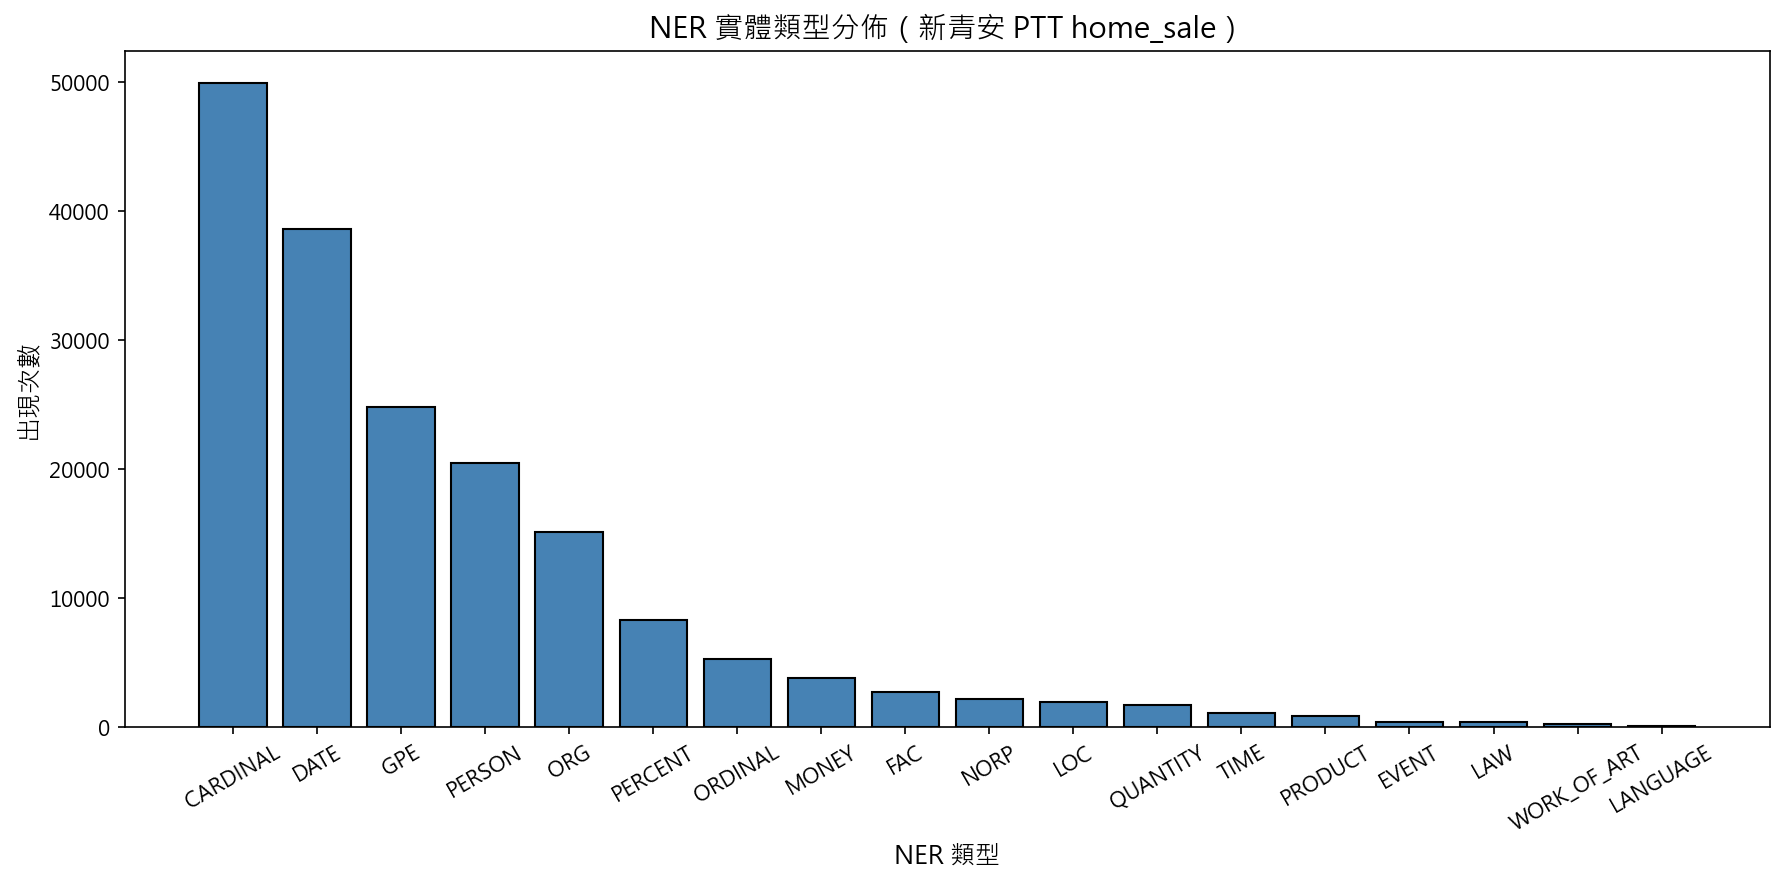

In [33]:
# ============================================================
# 探索分析 - NER 命名實體辨識
# ============================================================

# NER 種類有哪些
print("NER 種類：")
print(entity_table['ner'].unique())

# 統計各類型數量
ner_count = entity_table.groupby(['ner'])['ner'].count().reset_index(name='count')\
            .sort_values('count', ascending=False)
print("\nNER 類型統計：")
print(ner_count)

# 圖表：NER 類型分佈
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(ner_count['ner'], ner_count['count'], color='steelblue', edgecolor='black')
ax.set_title('NER 實體類型分佈（新青安 PTT home_sale）', fontsize=14)
ax.set_xlabel('NER 類型', fontsize=12)
ax.set_ylabel('出現次數', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('ner_distribution.png', dpi=150)
plt.show()

討論內容高度集中於 CARDINAL（數字） 與 DATE（日期），顯示網友在討論新青安時，關注貸款成數、利率數值、寬限期年限及政策實施的時間點，討論氛圍具有強烈的數據導向與時效性。

GPE（行政區） 以及 PERSON/ORG（人物與組織） 的標籤頻率也相當高；這代表「特定熱門區域」的熱度與「政府/特定組織」的政策發布，共同構成了網友在 PTT 房板討論新青安時的核心焦點

### NER 深入分析：ORG / GPE / PERSON

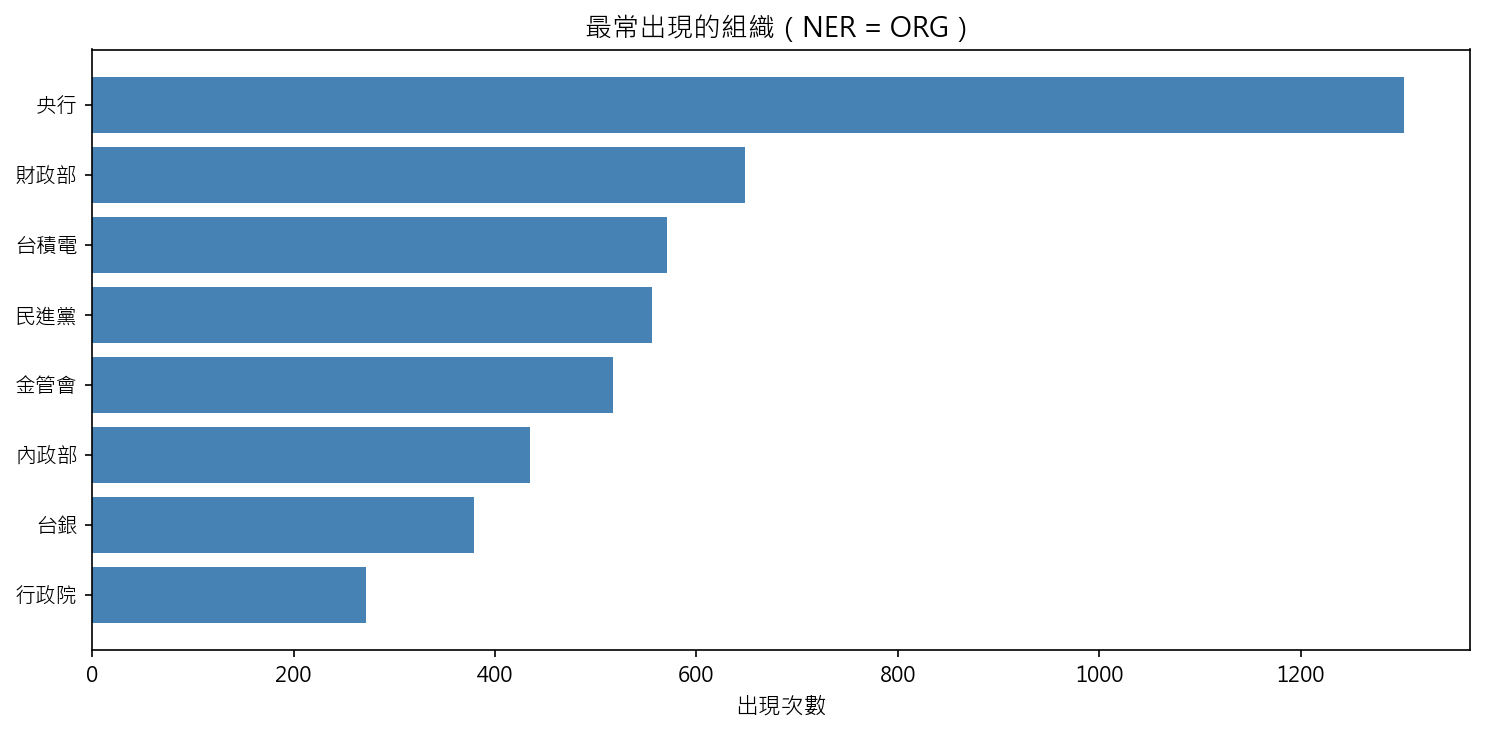

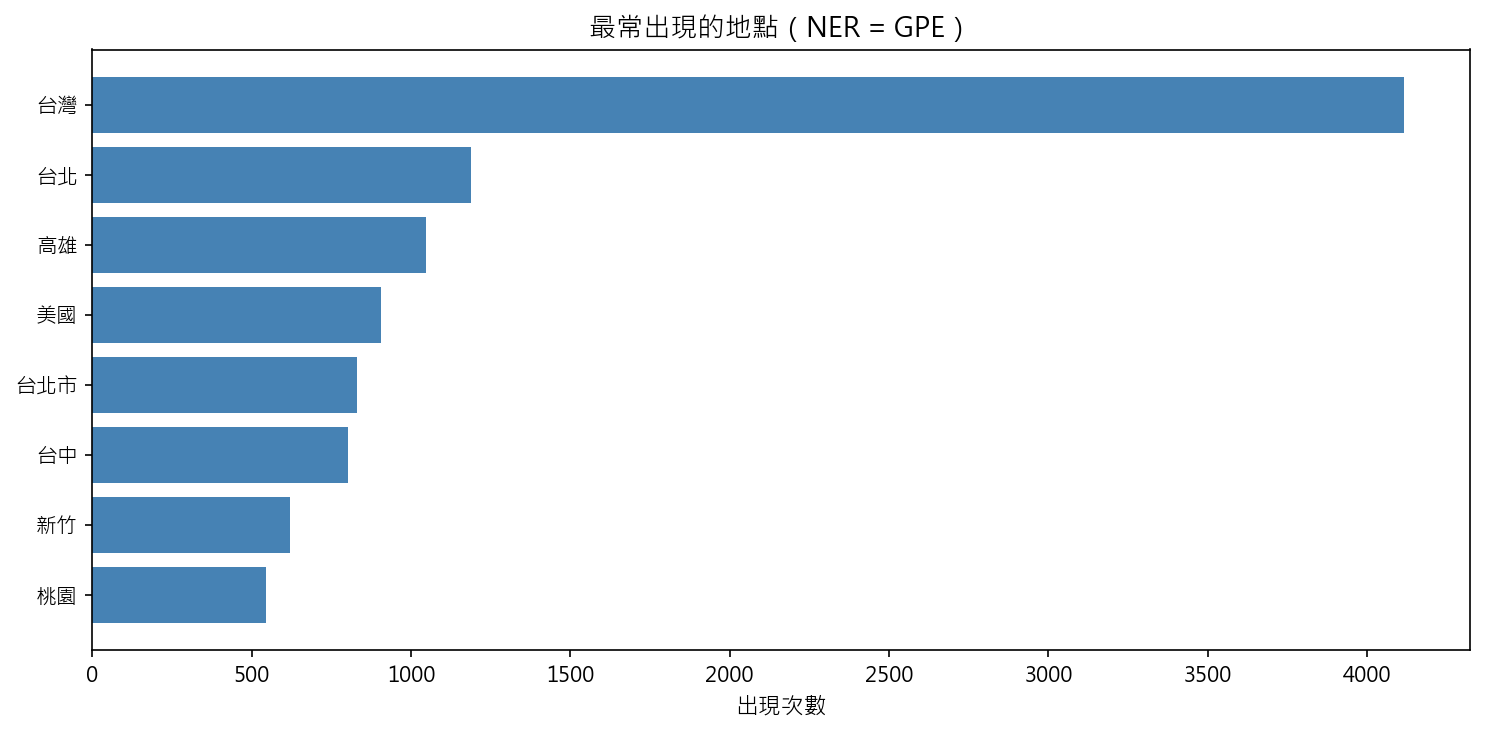

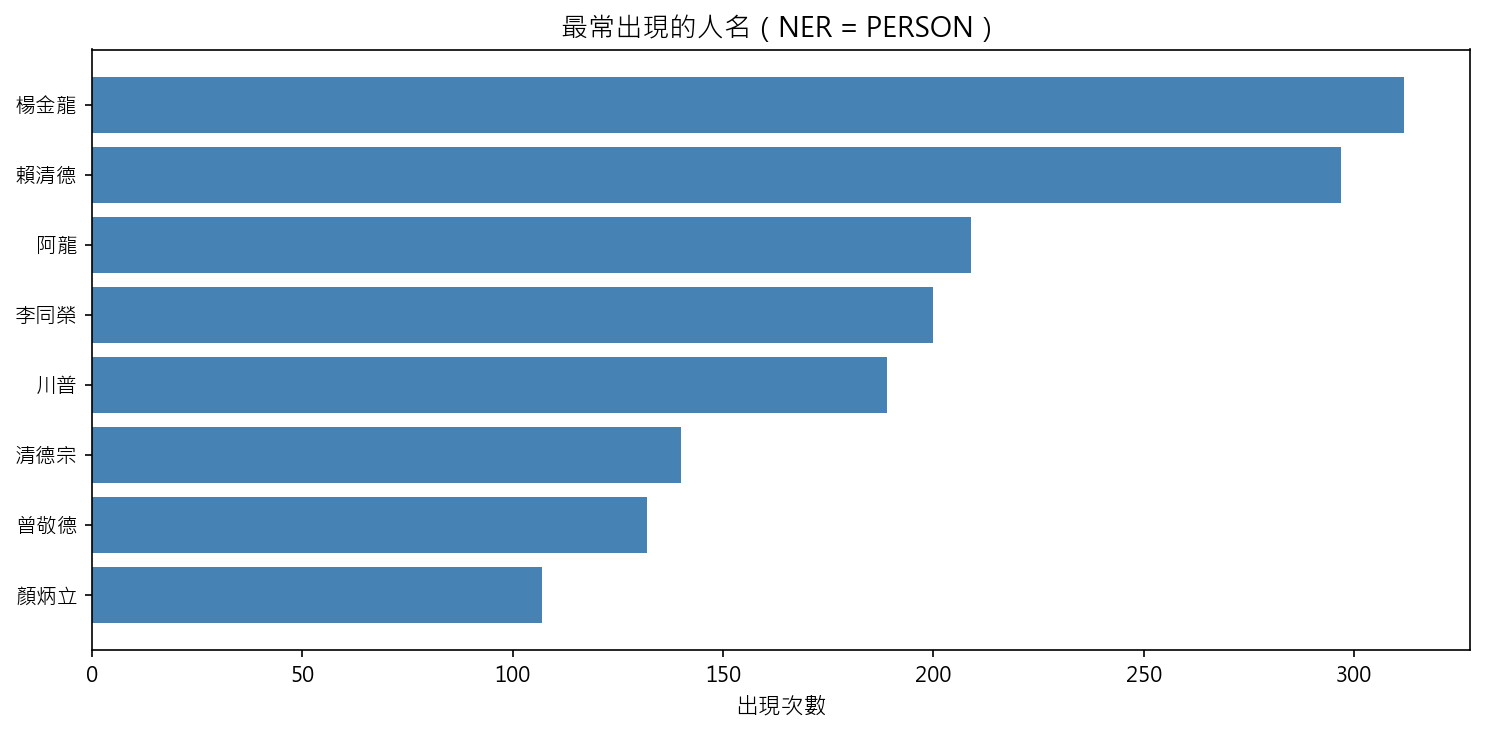

相關文章數：2758 篇


,system_id,artTitle,artDate
0,1,[新聞]新青安房貸今上路建商救命浮木來了？,2023-08-01 18:52:50
1,2,[新聞]台中7月房市衰退4都之最這1區幾乎腰斬,2023-08-01 20:05:11
2,3,[新聞]房市低迷台南7月買賣移轉棟數五年來最冷,2023-08-01 23:38:55
3,4,[新聞]減輕年輕人買房負擔！青安貸款升級版今上,2023-08-01 23:51:28
4,5,Re:[閒聊]85年次以後的年輕工程師有多慘？,2023-08-02 01:28:01


In [34]:
# ============================================================
# NER 深入分析：找出最常出現的組織、地點、人名
## ============================================================

# 需要從 NER 結果中排除的誤判詞
NER_BLACKLIST = {'新青安', '青安',"魯空","賴","金龍","柯"}

for ner_type, label in [('ORG', '組織'), ('GPE', '地點'), ('PERSON', '人名')]:
    subset = entity_table[entity_table['ner'] == ner_type]
    if subset.empty:
        continue
    
    # ✅ 新增：排除誤判詞
    subset = subset[~subset['word'].isin(NER_BLACKLIST)]
    
    top = subset.groupby('word')['word'].agg(['count'])\
                .sort_values('count', ascending=False).head(8).reset_index()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(top['word'], top['count'], color='steelblue')
    ax.invert_yaxis()
    ax.set_title(f'最常出現的{label}（NER = {ner_type}）', fontsize=13)
    ax.set_xlabel('出現次數', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'ner_{ner_type}.png', dpi=150)
    plt.show()

# 找出含「新青安」的相關文章
keyword_list = ['新青安', '青安貸款', '青安房貸', '青安']
selected_df = df[df['artContent'].str.contains('|'.join(keyword_list), regex=True, na=False)]
print(f"相關文章數：{selected_df.shape[0]} 篇")
selected_df[['system_id', 'artTitle', 'artDate']].head(5)



政策機關與核心人物： ORG 與 PERSON 類別以央行、財政部及楊金龍、賴清德最為頻繁，顯示政府決策者的立場與限貸令動向，是版上討論新青安的頭號焦點。

地理區域分布： GPE 實體則高度集中於六都與新竹房市，反映出政策討論熱度與全台主要都會區的房價波動與交易現況密不可分。

## 4.4 探索分析：POS

POS 詞性統計 Top 12：
    pos   count
18   Na  472903
5     D  392825
40   VC  200965
46   VH  186736
27  Neu  108869
7    DE   88774
20   Nc   88119
28   Nf   85536
30   Nh   80495
32    P   78328
37   VA   72614
43   VE   67366


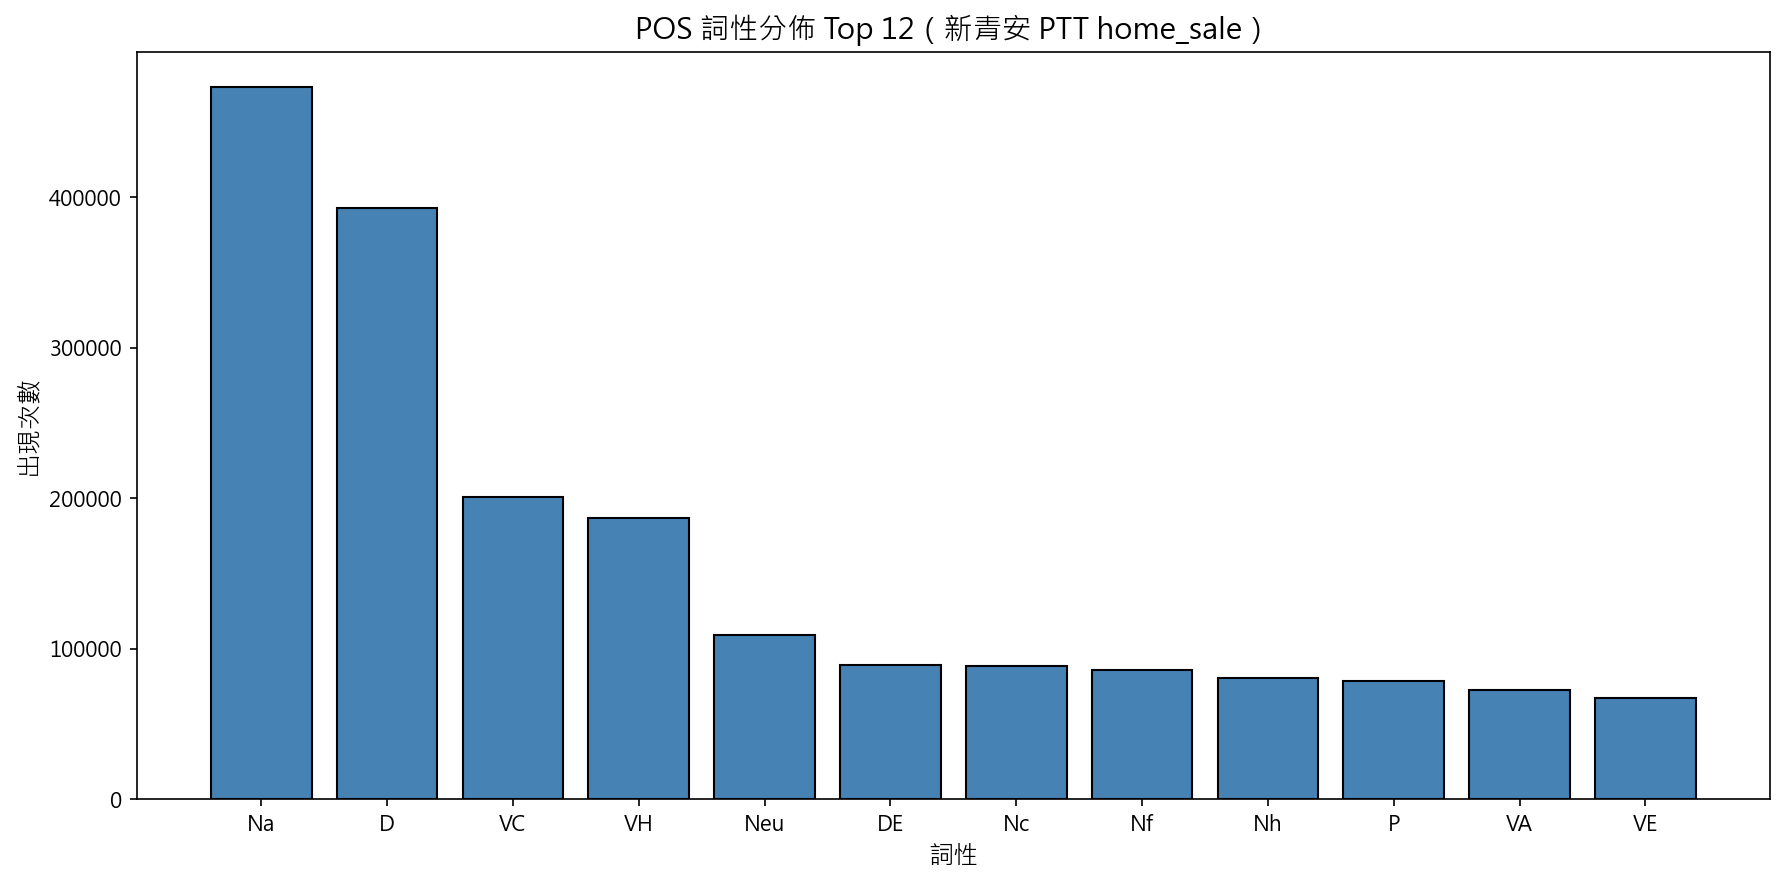

In [35]:
# ============================================================
# 探索分析 - POS 詞性標註
# ============================================================

# 過濾標點符號類
punct_pos = ['COMMACATEGORY', 'PARENTHESISCATEGORY', 'PERIODCATEGORY',
             'COLONCATEGORY', 'PAUSECATEGORY', 'EXCLAMATIONCATEGORY']
pos_filter = pos_table[~pos_table['pos'].isin(punct_pos)]

# 各詞性數量統計（Top 12）
pos_count = pos_filter.groupby('pos')['pos'].count()\
            .reset_index(name='count')\
            .sort_values('count', ascending=False).head(12)
print("POS 詞性統計 Top 12：")
print(pos_count)

# 圖表
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(pos_count['pos'], pos_count['count'], color='steelblue', edgecolor='black')
ax.set_title('POS 詞性分佈 Top 12（新青安 PTT home_sale）', fontsize=14)
ax.set_xlabel('詞性', fontsize=12)
ax.set_ylabel('出現次數', fontsize=12)
plt.tight_layout()
plt.savefig('pos_distribution.png', dpi=150)
plt.show()

詞性以名詞為最大宗，接下來我們來進一步看高頻名詞有哪些。

### POS 高頻名詞 + 文字雲

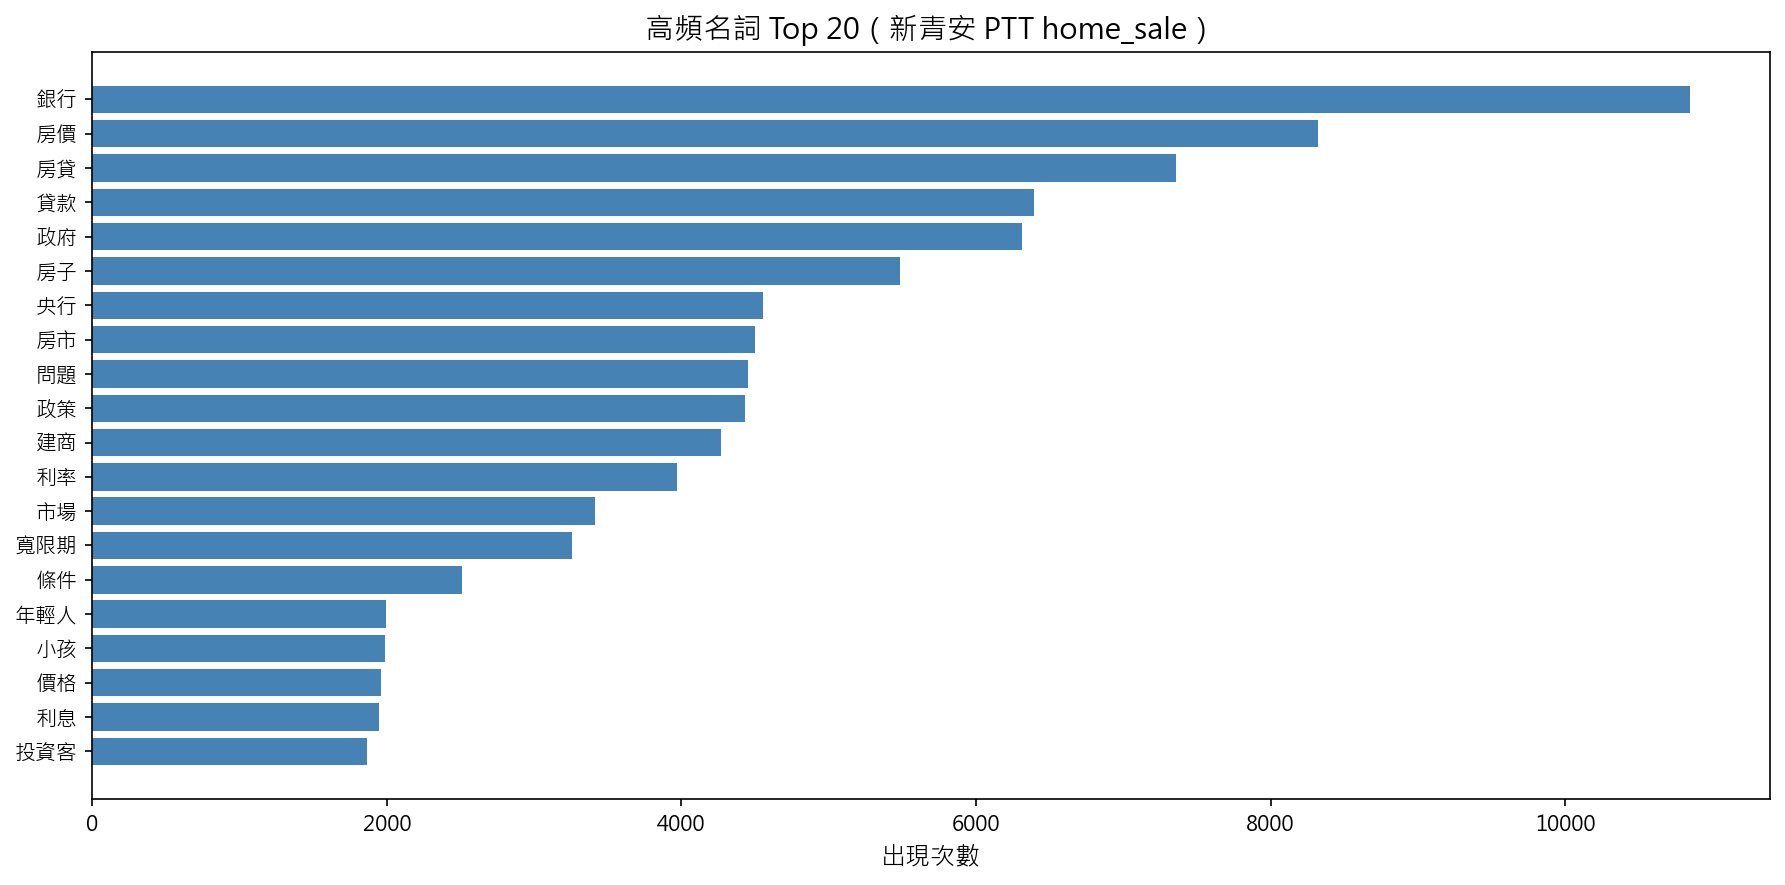

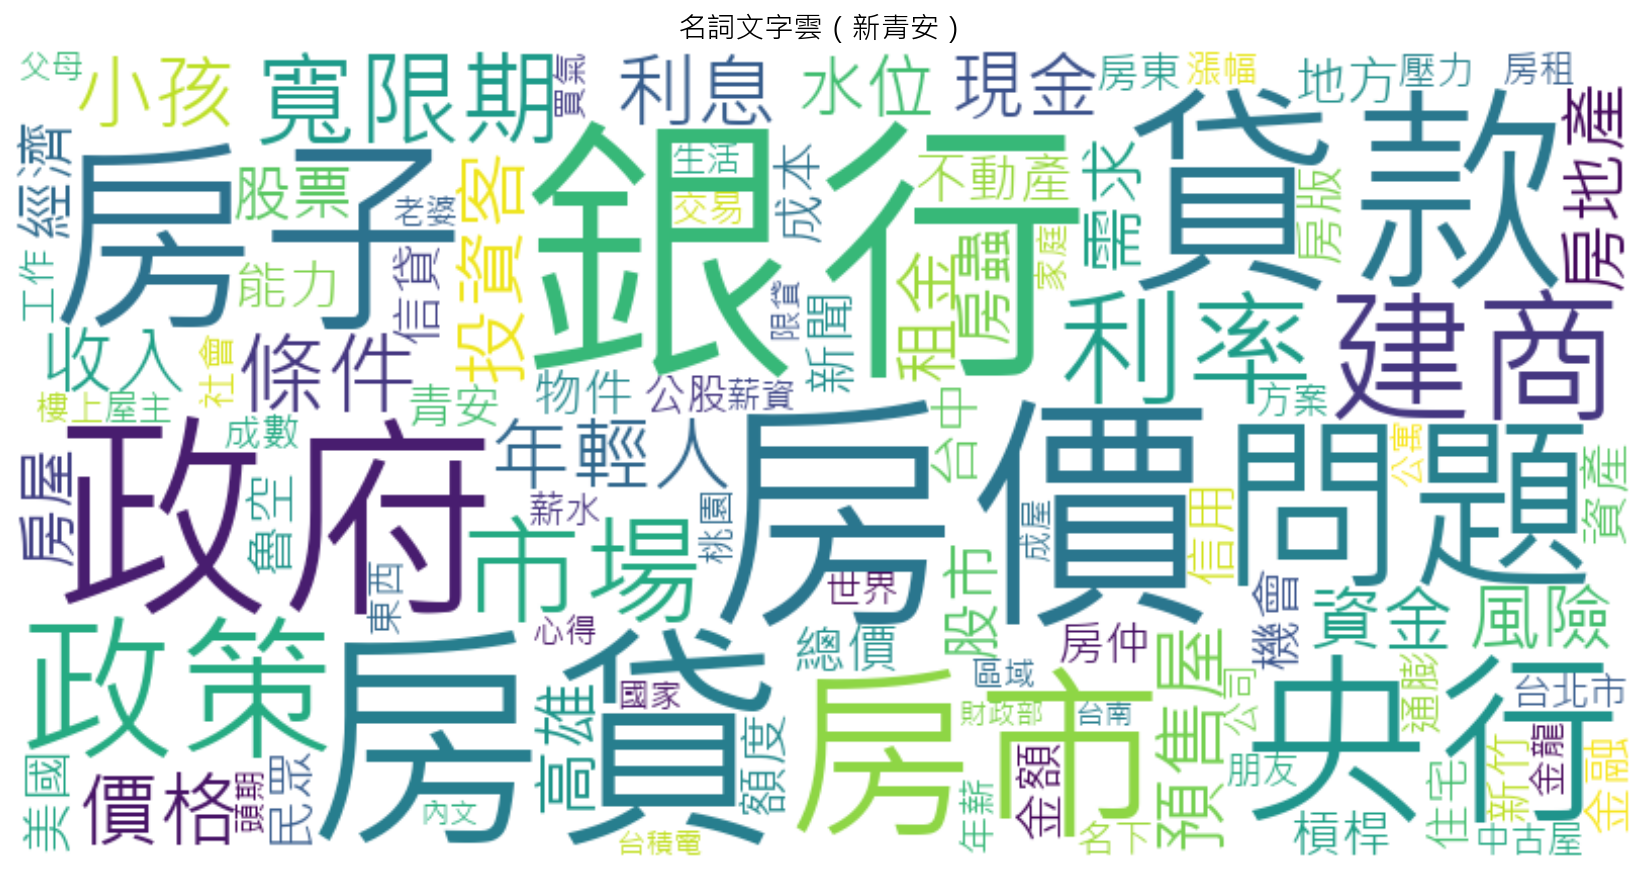

In [36]:
# ============================================================
# 高頻名詞分析 + 文字雲
# ============================================================

# 停用字直接使用已建立的 stopwords（已包含通用停用詞）
# 在此基礎上補充 CKIP 名詞分析專屬的主題停用詞
stop_words_home = set(stopwords)

# 篩選名詞（Na 普通名詞, Nb 專有名詞, Nc 地方詞）
noun_pos = pos_table[pos_table['pos'].isin(['Na', 'Nb', 'Nc'])]
noun_words = noun_pos[~noun_pos['word'].isin(stop_words_home) & (noun_pos['word'].str.len() >= 2)]

# 過濾純數字詞（如 40、1.775、75%）
noun_words = noun_words[~noun_words['word'].str.match(r'^\d+\.?\d*%?$')]

# Top 20 名詞長條圖
noun_count = noun_words.groupby('word')['word'].count()\
             .reset_index(name='count')\
             .sort_values('count', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(noun_count['word'], noun_count['count'], color='steelblue')
ax.invert_yaxis()
ax.set_title('高頻名詞 Top 20（新青安 PTT home_sale）', fontsize=14)
ax.set_xlabel('出現次數', fontsize=12)
plt.tight_layout()
plt.savefig('noun_top20.png', dpi=150)
plt.show()

# 文字雲
wordcloud = WordCloud(
    stopwords=stop_words_home,
    collocations=False,
    font_path='C:/Windows/Fonts/msjh.ttc',
    width=800,
    height=400,
    max_words=100,
    background_color='white'
)
wordcloud.generate(' '.join(noun_words['word']))

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('名詞文字雲（新青安）', fontsize=14)
plt.savefig('wordcloud_noun.png', dpi=150)
plt.show()

從高頻名詞長條圖跟文字雲來看

金融實務為核心： 「銀行」、「房價」、「貸款」位居前列，顯示網友討論高度聚焦於借貸門檻與資金成本，特別是「寬限期」與「利率」等實務條件。

政策與社會觀點： 除政府、央行等政策主體外，「年輕人」、「小孩」及「投資客」的高頻出現，反映出社群正熱烈討論該政策對首購族支持度與市場投機行為的社會影響。

## 4.4 SnowNLP 情緒分析

In [37]:
# ============================================================
# 利用 SnowNLP 進行情緒分析
# ============================================================
# 做法：以「句子」為單位計算情緒分數，再 merge 回文章日期

# 先用 sentence_table merge 文章日期資訊
sentiment_date = pd.merge(
    sentence_table,
    df[['system_id', 'artDate']],
    on='system_id',
    how='left'
).dropna()

print(f"✅ 合併完成，共 {len(sentiment_date)} 筆句子")
sentiment_date.head(3)

✅ 合併完成，共 269476 筆句子


,system_id,sentence,artDate
0,1,連結,2023-08-01 18:52:50
1,1,/////5621/7338630,2023-08-01 18:52:50
2,1,__,2023-08-01 18:52:50


### 計算每句情緒分數

In [38]:
# ============================================================
# 計算情緒分數（sentence 層級）
# ============================================================

def get_sentiment(text):
    try:
        if not text or len(str(text).strip()) < 3:
            return None
        return round(SnowNLP(str(text)).sentiments, 4)
    except:
        return None

print("⏳ 計算情緒分數中...")
sentiment_date['sentiment'] = sentiment_date['sentence'].apply(get_sentiment)
sentiment_date = sentiment_date.dropna(subset=['sentiment'])

print(f"✅ 完成，有效句子數：{len(sentiment_date)}")
print(f"平均情緒分數：{sentiment_date['sentiment'].mean():.4f}")
sentiment_date.head(5)

⏳ 計算情緒分數中...
✅ 完成，有效句子數：258300
平均情緒分數：0.3353


,system_id,sentence,artDate,sentiment
1,1,/////5621/7338630,2023-08-01 18:52:50,0.5000
4,1,經濟日報記者游智文即時報導,2023-08-01 18:52:50,0.0092
5,1,新版青年安心成家優惠房貸專案今1日上路，元宏不動產加值服務平台研究總監陳傑鳴,2023-08-01 18:52:50,0.6510
6,1,表示，新青安房貸降拉延的措施，除了吸引首購進場，對於部分,2023-08-01 18:52:50,0.5354
7,1,面臨危機的建商而言，也是救命浮木,2023-08-01 18:52:50,0.9933


### 情緒分類 + 分佈圖

情緒分佈：
sentiment_label
負面    161615
正面     60362
中性     36323
Name: count, dtype: int64


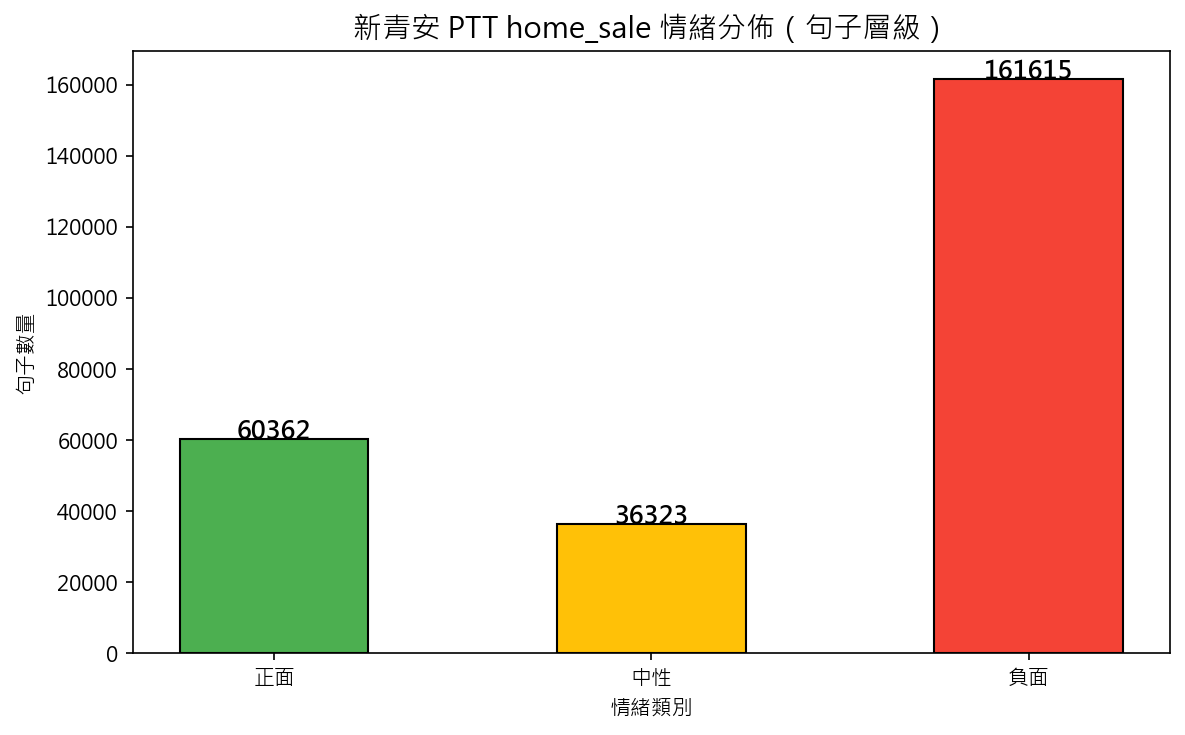

In [39]:
# ============================================================
# 情緒分類與分佈視覺化
# ============================================================

def classify(score):
    if score >= 0.6:   return '正面'
    elif score <= 0.4: return '負面'
    else:              return '中性'

sentiment_date['sentiment_label'] = sentiment_date['sentiment'].apply(classify)

label_counts = sentiment_date['sentiment_label'].value_counts()
print("情緒分佈：")
print(label_counts)

# 長條圖
COLOR_MAP = {'正面': '#4CAF50', '中性': '#FFC107', '負面': '#F44336'}
ordered = ['正面', '中性', '負面']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    ordered,
    [label_counts.get(l, 0) for l in ordered],
    color=[COLOR_MAP[l] for l in ordered],
    edgecolor='black', width=0.5
)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            str(int(bar.get_height())),
            ha='center', fontsize=12, fontweight='bold')
ax.set_title('新青安 PTT home_sale 情緒分佈（句子層級）', fontsize=14)
ax.set_xlabel('情緒類別')
ax.set_ylabel('句子數量')
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150)
plt.show()

負面情緒佔絕對主導： 負面句子數量（約 16 萬）遠超正面與中性之總和，反映出社群對於新青安引發的房價推升、市場亂象及限貸配套措施存有高度不滿。

### 情緒時間趨勢

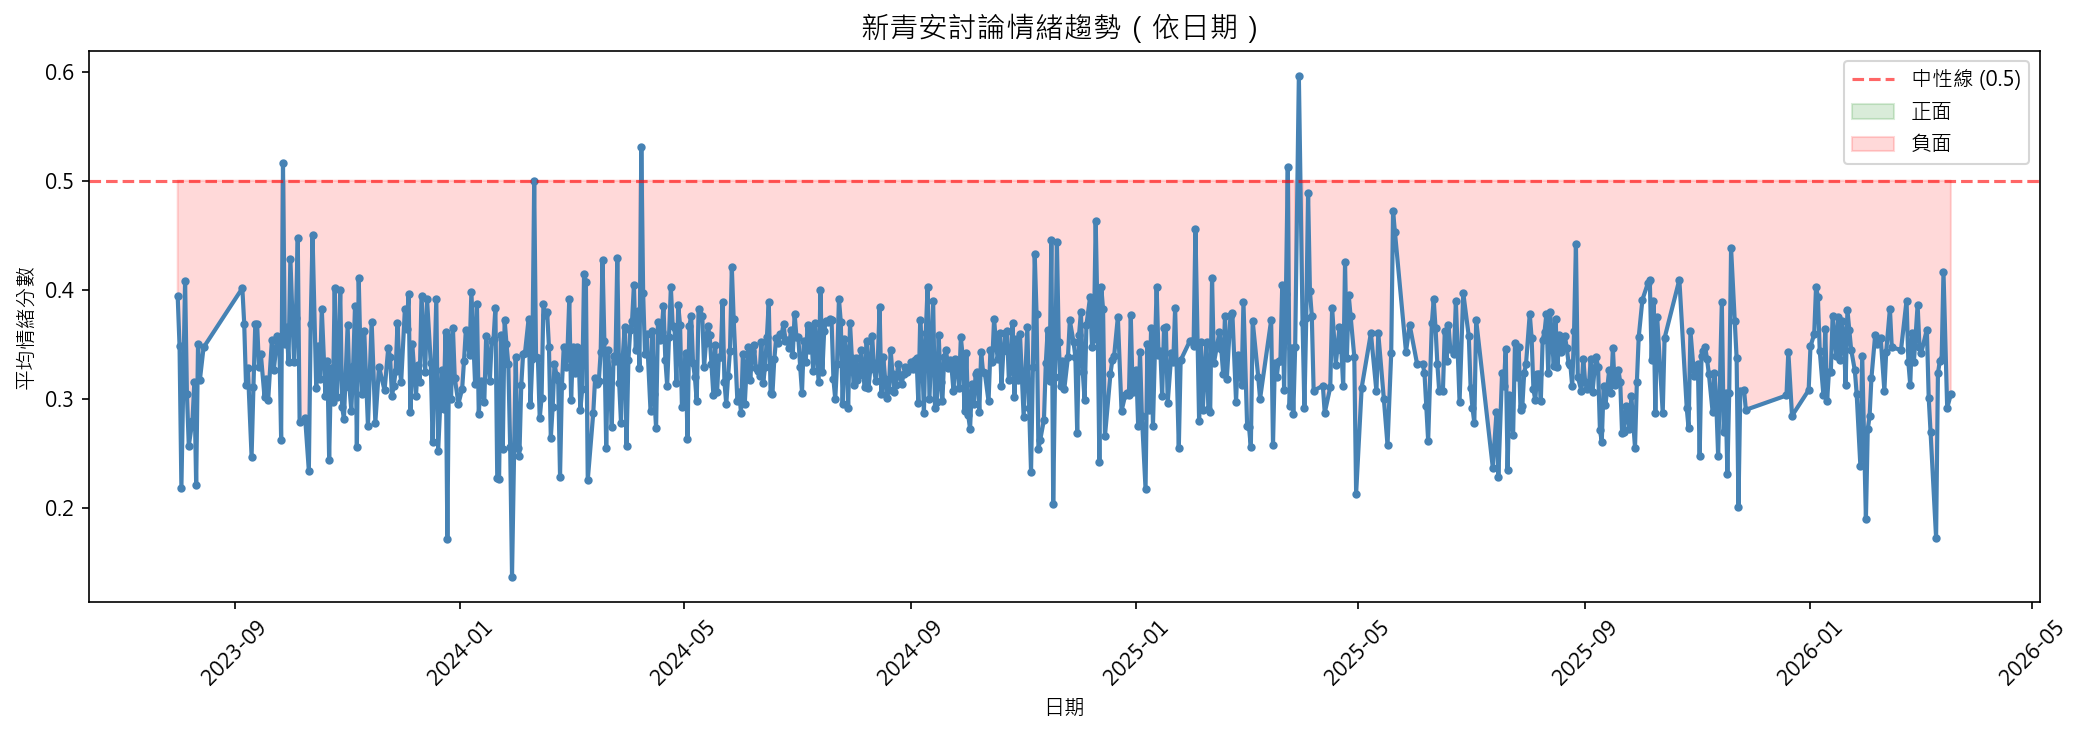

In [40]:
# ============================================================
# 情緒隨時間趨勢（教材核心圖表）
# ============================================================

sentiment_date['artDate'] = pd.to_datetime(sentiment_date['artDate'])
sentiment_date['date_only'] = sentiment_date['artDate'].dt.date

daily = sentiment_date.groupby('date_only')['sentiment'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['date_only'], daily['sentiment'],
        marker='o', color='steelblue', linewidth=2, markersize=3)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.6, label='中性線 (0.5)')
ax.fill_between(daily['date_only'], daily['sentiment'], 0.5,
                where=(daily['sentiment'] >= 0.5), alpha=0.15, color='green', label='正面')
ax.fill_between(daily['date_only'], daily['sentiment'], 0.5,
                where=(daily['sentiment'] < 0.5),  alpha=0.15, color='red',   label='負面')
ax.set_title('新青安討論情緒趨勢（依日期）', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('平均情緒分數')
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('sentiment_trend.png', dpi=150)
plt.show()

長期情緒低迷且穩定： 平均情緒分數長期處於中性線（0.5）以下的負面區域，顯示自政策推行以來，社群輿論始終維持較高的不滿與批判情緒。

波動與特定事件掛鉤： 趨勢圖中出現多個顯著的情緒崩跌點，反映出政策細節調整、限貸令發布(2024年9/19第七波限貸令)或房價急漲等特定時間點，容易引發劇烈的情緒震盪。

### 負面文章的高頻詞文字雲

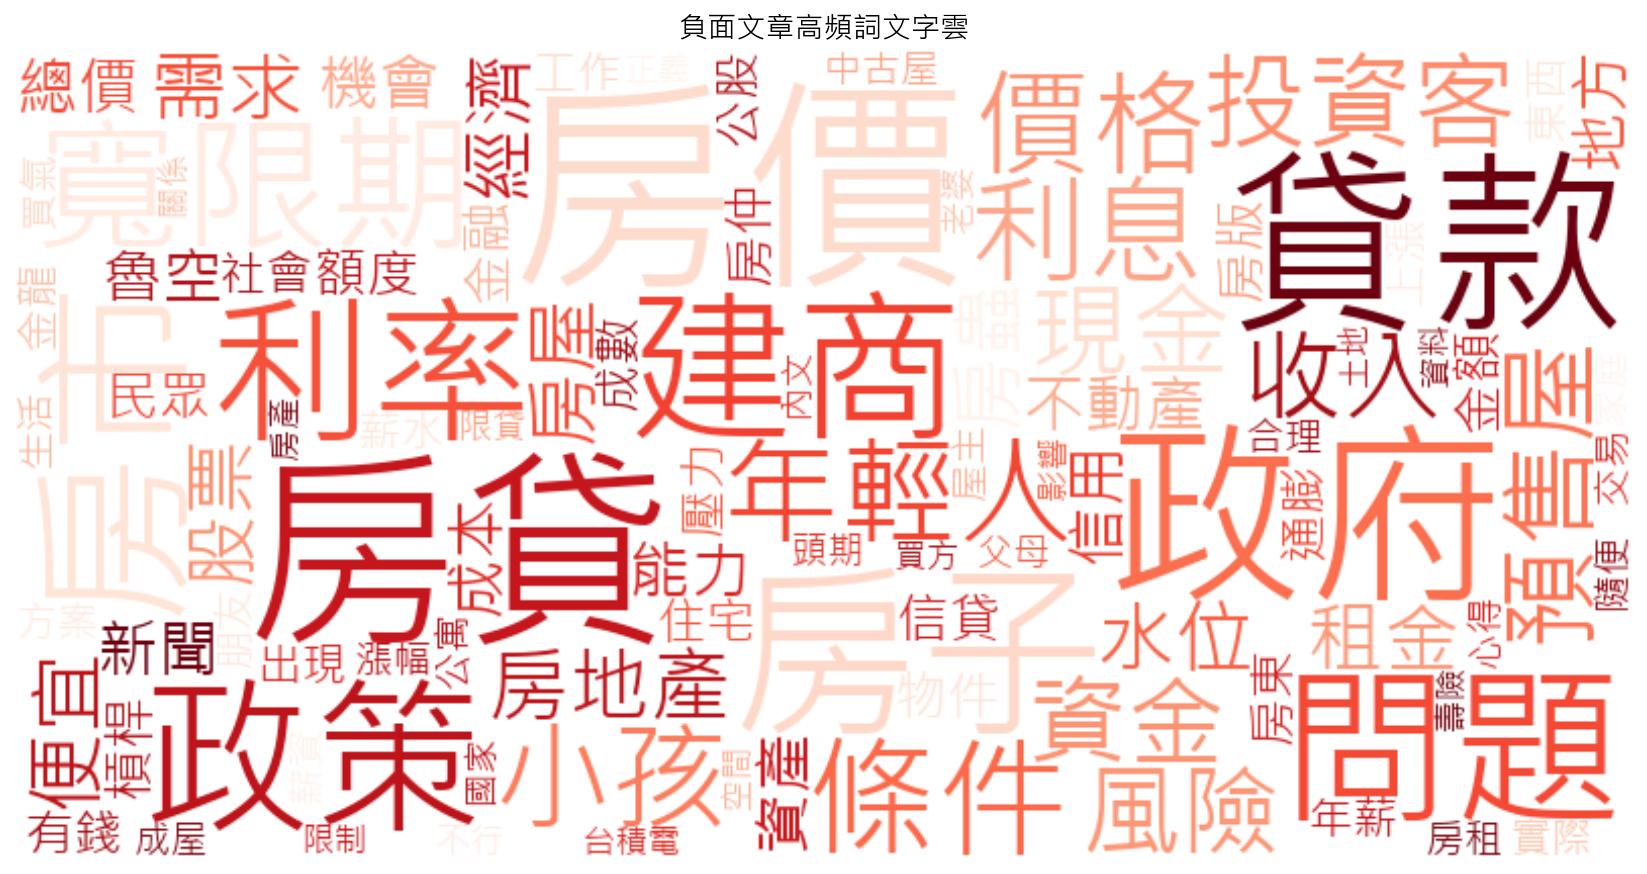

✅ 已儲存：wordcloud_negative.png


In [41]:
# ============================================================
# 負面文章的高頻詞比較
# ============================================================

# 取出負面句子對應的 system_id
neg_ids = sentiment_date[sentiment_date['sentiment_label'] == '負面']['system_id'].unique()

# 從 pos_table 取出對應的名詞
for label, ids, color, fname in [
        ('負面', neg_ids, 'Reds',  'wordcloud_negative.png')
]:
    pos_words = pos_table[
        (pos_table['system_id'].isin(ids)) &
        (pos_table['pos'].isin(['Na', 'Nb', 'VH'])) &
        (~pos_table['word'].isin(stop_words_home)) &
        (pos_table['word'].str.len() >= 2)
    ]
    if pos_words.empty:
        print(f"⚠️ {label}文章詞彙為空，跳過")
        continue

    wc = WordCloud(
        stopwords=stop_words_home,
        collocations=False,
        font_path='C:/Windows/Fonts/msjh.ttc',
        width=800, height=400,
        max_words=100,
        background_color='white',
        colormap=color
    )
    wc.generate(' '.join(pos_words['word']))

    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'{label}文章高頻詞文字雲', fontsize=14)
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"✅ 已儲存：{fname}")

### 負面情緒深因分析：為何不滿新青安？

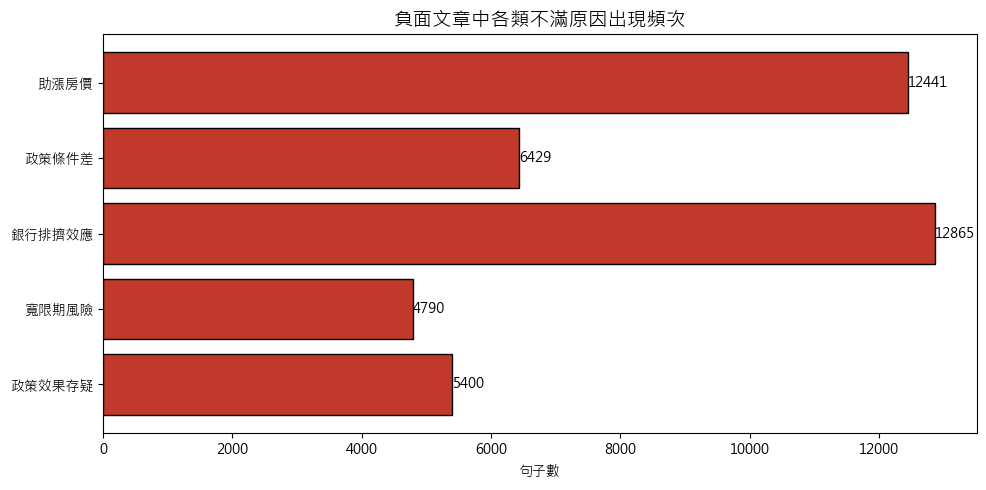

In [ ]:
# 將負面詞彙高頻文字定義負面原因主題詞籃
concern_categories = {
    '助漲房價': ['房價', '漲價', '炒房', '投機', '高房價', '買不起', '越來越貴'],
    '政策條件差': ['門檻', '限制', '資格', '排富', '條件', '不公平', '只有', '無法申請'],
    '銀行排擠效應': ['銀行', '額度', '滿了', '停辦', '暫停', '排隊', '拒貸', '72-2'],
    '寬限期風險': ['寬限期', '到期', '本金', '還不起', '地雷', '泡沫', '崩盤'],
    '政策效果存疑': ['根本', '沒用', '無效', '假的', '騙', '政治', '選票', '作秀'],
}

# 在負面文章的 sentence 層級中計算各類出現次數
neg_sentences = sentence_table[sentence_table['system_id'].isin(neg_ids)]['sentence']

result = {}
for category, keywords in concern_categories.items():
    count = neg_sentences.str.contains('|'.join(keywords), na=False).sum()
    result[category] = count

# 繪圖
import matplotlib.pyplot as plt
categories = list(result.keys())
counts = list(result.values())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(categories, counts, color='#C0392B', edgecolor='black')
ax.invert_yaxis()
ax.set_title('負面文章中各類不滿原因出現頻次', fontsize=14)
ax.set_xlabel('句子數')
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            str(cnt), va='center', fontsize=10)
plt.tight_layout()
plt.show()

兩大不滿核心： 「銀行排擠效應」與「助漲房價」是引發負面情緒的最主因，顯示網民極度在意新青安政策導致的核貸困難，以及政策性帶動房價走揚的副作用。

# 5. 結論

### **整體情緒傾向：中立偏負面**


### **情緒三階段演變**

2023 下半年：政策發布初期，正向情緒短暫領先，反映出首購族對於降低購屋門檻的樂觀預期。

2024 下半年：新青安政策下導致房價上漲、購屋需求擴增，導致央行採取限貸令政策，引起集體焦慮

2025 至今：輿論呈現高度極化與敏感，任何政策訊號皆會立即引發劇烈的情緒震盪

### **不滿根源**

負面詞彙中，「風險」、「壓力」與「違約」等關鍵詞高頻出現。

這顯示市場參與者高度關注長年期貸款（如 40 年房貸）帶來的財務槓桿風險，以及銀行法水位限制（如 72-2 條）引發的信用收緊焦慮。

民眾不滿的是政策助長房價、銀行排擠效應造成多人影響。


